# Chicago Crime

**Author:** Erik Pak 
**Date:** 04/2026 
**Data:** Chicago Data Portal - Crime Incidents 2001-2025


https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data

https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/about_data

___
## Scope:
We are modeling crime incidence as a multivariate, non-stationary stochastic process and detecting shifts in crime types via structural break detection in latent distributional parameters across the pre-COVID, COVID, and post-COVID periods. How crime structures differ across eras, and which crimes move together in each era.

## Era Definitions

| Era    | Period         | Months |
|------------|-------------------------|--------|
| Pre-COVID | Jan 2001 - Feb 2020   | 230  |
| COVID   | Mar 2020 - Dec 2022   | 34   |
| Post-COVID | Jan 2023 - April 2026   | 40   |

Era cutoff rationale: The COVID era begins in March 2020, coinciding with the Illinois stay-at-home order (March 21, 2020) and the WHO pandemic declaration (March 11, 2020). The post-COVID era begins in January 2023, following the expiration of Illinois's disaster proclamation and the effective end of major federal pandemic-era policies in late 2022. These boundaries are administrative and policy-based; the underlying behavioral and enforcement shifts may not align exactly with these dates.

> Era cutoff rationale: The COVID era begins in March 2020, coinciding with the Illinois stay-at-home order (March 21, 2020) and the WHO pandemic declaration (March 11, 2020). The post-COVID era begins in January 2023, reflecting the winding down of major pandemic-era policies and restrictions through late 2022. These boundaries are administrative and policy-based; the underlying behavioral and enforcement shifts may not align exactly with these dates.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn.preprocessing import StandardScaler
import ruptures as rpt

# Path + custom modules---
sys.path.append('../Src/') 
import clr_config as cfg
import clr_utilities as utils
import clr_eps_grid as grid
import clr_analyze_plot as plot
import clr_era as clr
import clr_pca_sign_normalization as pca_anchor

# Image Path
image_path = "../Image/"

# Seed
_RANDOM_STATE = 1776

# Library versions
versions = {
  "Python" : sys.version.split()[0],
  "Pandas" : pd.__version__,
  "NumPy"  : np.__version__,
  "Pyarrow" : pa.__version__,
  "Seaborn" : sns.__version__,
  "Matplot" : sys.modules['matplotlib'].__version__,
  "Ruptures": sys.modules['ruptures'].__version__,
  "Scipy"  : sys.modules['scipy'].__version__,
}
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=6, linewidth=100)

    Library  Version
0    Python   3.13.9
1    Pandas    2.3.3
2     NumPy    2.3.4
3   Pyarrow   22.0.0
4   Seaborn   0.13.2
5   Matplot   3.10.7
6  Ruptures  v1.1.10
7     Scipy   1.16.3


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,y_coordinate,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
8265318,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSSESS - CANNABIS 30 GRAMS OR LESS,N,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,...,1857566,pre_covid,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
7080787,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,APARTMENT,...,1854276,pre_covid,July,Saturday,Q3,2003-Q3,Evening,Larceny - Theft,True,Gresham
6396203,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,...,1903996,pre_covid,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
5818733,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,1916864,pre_covid,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
5312174,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,N,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,...,1914371,pre_covid,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


## Data Integration & Cleaning

In [3]:
# New column
df['year_month'] = df['date'].dt.strftime('%Y%m')
# Normalize era keys to consistent labels
df['era'] = (
    df['era']
    .map(cfg.era_map)
    .fillna(df['era'])
    .astype(str)                 # ensure all values are strings
    .astype('string[pyarrow]')   # Arrow conversion
)
# display
df.era.unique()

<ArrowStringArray>
['Pre-COVID', 'Post-COVID', 'COVID']
Length: 3, dtype: string

In [4]:
# get the dates of period in the dataset
start_date = pd.to_datetime(df[cfg.config_agg["_DATE_KEY"]].min(), format='%Y%m').date().strftime('%Y-%m')
end_date = pd.to_datetime(df[cfg.config_agg["_DATE_KEY"]].max(), format='%Y%m').date().strftime('%Y-%m') 
# print the date range
print(f"Dataset covers from {start_date} to {end_date}")

Dataset covers from 2001-01 to 2026-04


### Full Diagnostic 

In [5]:
# Normalize year_month to datetime (keep both versions)
df['year_month_dt'] = pd.to_datetime(df['year_month'], format='%Y%m')

# Identity check
identical = bool((df['primary_description'] == df['primary_type']).all())
print(f"primary_description == primary_type: {identical}\n")

# Distinct primary_descriptions
prim_list = sorted([str(x) for x in df['primary_description'].dropna().unique()])
print(f"Distinct primary_descriptions: {len(prim_list)}")
for c in prim_list:
    print(f"  - {c}")
print()

# Distinct FBI categories
fbi_list = sorted([str(x) for x in df['fbi_code_desc'].dropna().unique()])
print(f"Distinct fbi_code_desc: {len(fbi_list)}")
for c in fbi_list:
    print(f"  - {c}")
print()

# Era boundaries are actually encoded
era_bounds = (df.groupby('era')['year_month_dt']
              .agg(['min', 'max', 'nunique'])
              .rename(columns={'nunique': 'n_months'}))
print("Era boundaries:")
print(era_bounds.to_string())
print()

# index_code vs fbi_index_code
print("index_code vs fbi_index_code:")
print(pd.crosstab(df['index_code'], df['fbi_index_code'], dropna=False))

primary_description == primary_type: False

Distinct primary_descriptions: 32
  - ARSON
  - ASSAULT
  - BATTERY
  - BURGLARY
  - CONCEALED CARRY LICENSE VIOLATION
  - CRIMINAL DAMAGE
  - CRIMINAL SEXUAL ASSAULT
  - CRIMINAL TRESPASS
  - DECEPTIVE PRACTICE
  - GAMBLING
  - HOMICIDE
  - HUMAN TRAFFICKING
  - INTERFERENCE WITH PUBLIC OFFICER
  - INTIMIDATION
  - KIDNAPPING
  - LIQUOR LAW VIOLATION
  - MOTOR VEHICLE THEFT
  - NARCOTICS
  - NON-CRIMINAL
  - OBSCENITY
  - OFFENSE INVOLVING CHILDREN
  - OTHER NARCOTIC VIOLATION
  - OTHER OFFENSE
  - PROSTITUTION
  - PUBLIC INDECENCY
  - PUBLIC PEACE VIOLATION
  - RITUALISM
  - ROBBERY
  - SEX OFFENSE
  - STALKING
  - THEFT
  - WEAPONS VIOLATION

Distinct fbi_code_desc: 26
  - Aggravated Assault
  - Aggravated Battery
  - Arson
  - Burglary
  - Criminal Sexual Assault
  - Disorderly Conduct
  - Drug Abuse Violations
  - Embezzlement
  - Forgery and Counterfeiting
  - Fraud
  - Gambling
  - Homicide - 1st or 2nd Degree
  - Involuntary Manslaugh

### Check missingness

In [6]:
# Check integrity and missingness
missingness_results = utils.run_integrity_report(df)


--------------------------------------------------
 📑  PANEL INTEGRITY & SPARSITY DIAGNOSTIC
--------------------------------------------------
  • Date Horizon   : 2001-01 to 2026-04
  • Total Months   : 304
  • Feature Space  : 26 crime categories
  • Total Panel    : 7,904 (expected combinations)
  • Actual Density : 7,627 (observed rows)
--------------------------------------------------
  ⚠️ Completeness  : 96.50%
  🔍 Missing Gaps  : 277 rows
  👯 Duplicates    : 0 rows
--------------------------------------------------

 🔥  CRITICAL: TRUE MISSING GAPS
    (These months are entirely absent from the raw data)
    ↳ Involuntary Manslaughter / Reckless Homicide   |  233 months missing
    ↳ Gambling                                       |   28 months missing
    ↳ Embezzlement                                   |   12 months missing
    ↳ Stolen Property (Buy, Receive, Possess)        |    2 months missing
    ↳ Prostitution                                   |    2 months missing

 🧪 

####  Onset Diagnostic ('Involuntary Manslaughter / Reckless Homicide)

In [7]:
# Crime type to analyze
sus = 'Involuntary Manslaughter / Reckless Homicide'

# Build a monthly time series of counts for this crime type
s = (df[df['fbi_code_desc'] == sus]      # filter to the selected crime
     .groupby('year_month_dt')           # group by month
     .size()                             # count incidents per month
     .sort_index())                      # ensure chronological order

# Basic non-zero occurrence diagnostics
print(f"First non-zero month: {s[s > 0].index.min():%Y-%m}")  # earliest month with >0 incidents
print(f"Last non-zero month:  {s[s > 0].index.max():%Y-%m}")  # latest month with >0 incidents
print(f"Total non-zero months: {(s > 0).sum()}")              # number of months with any incidents

# Summary statistics for the monthly counts
print(f"\nMonthly count statistics:")
print(s.describe())                      # mean, std, min, quartiles, max

# Yearly aggregation: how this crime behaves year by year
yearly = pd.DataFrame({
    'months_with_data': s.groupby(s.index.year).apply(lambda x: (x > 0).sum()),  # months with > 0 incidents
    'total_count':      s.groupby(s.index.year).sum(),                           # total incidents per year
    'max_in_year':      s.groupby(s.index.year).max(),                           # worst month in each year
})

# Display the yearly pattern in a readable table
print(f"\nYearly pattern:")
print(yearly.to_string())

First non-zero month: 2002-11
Last non-zero month:  2025-09
Total non-zero months: 71

Monthly count statistics:
count    71.000000
mean      1.253521
std       0.499094
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
dtype: float64

Yearly pattern:
               months_with_data  total_count  max_in_year
year_month_dt                                            
2002                          1            1            1
2003                          3            3            1
2004                          1            1            1
2005                          1            2            2
2006                          5            6            2
2011                          1            1            1
2012                          1            1            1
2013                          1            1            1
2014                          2            2            1
2015                          5            6            2
2016   

#### Confirm

In [8]:
iucr_by_year = (df[df['fbi_code_desc'] == sus]
                .assign(yr=lambda d: d['date'].dt.year)
                .groupby(['yr', 'iucr'])
                .size()
                .reset_index(name='n'))
print(iucr_by_year.to_string(index=False))

# Also: what IUCR codes appear in this FBI category overall?
codes = df.loc[df['fbi_code_desc'] == sus, 'iucr'].value_counts()
print(f"\nIUCR codes mapped to this FBI category:")
print(codes)

  yr iucr  n
2002 0142  1
2003 0141  1
2003 0142  2
2004 0142  1
2005 0142  2
2006 0142  6
2011 0142  1
2012 0142  1
2013 0141  1
2014 0141  1
2014 0142  1
2015 0142  6
2016 0142  4
2017 0142  4
2018 0142 12
2019 0141  2
2019 0142  8
2020 0142  9
2021 0142  7
2022 0141  1
2022 0142  6
2023 0142  6
2024 0142  3
2025 0142  3

IUCR codes mapped to this FBI category:
iucr
0142    83
0141     6
Name: count, dtype: int64[pyarrow]


#### 📌 Summary
> - Involuntary Manslaughter / Reckless Homicide (IUCR codes 0141 and 0142) was excluded from the compositional analysis because the category was too sparse for reliable modeling. Across 304 months of data, it appeared in only 23.4% of months and totaled just 89 incidents overall, averaging fewer than one incident every three months (0.29 per month). Including such a low-frequency category in a high-dimensional compositional framework could introduce instability and distort the overall covariance structure. As a result, the final compositional analysis was conducted using the remaining 25 FBI crime categories, all of which showed at least 90.8% monthly coverage.

> - Although excluded from formal modeling, the category still showed an observable increase after 2017. Between 2018 and 2023, Chicago recorded an average of roughly 7 incidents per year (ranging from 6 to 12), compared with about 2 incidents per year (ranging from 1 to 4) between 2011 and 2017. While the counts remain too small for dependable statistical inference, the increase may reflect changes in prosecutorial practices related to drug-induced homicide cases or shifts in how fatal traffic incidents were classified during that period.

#### User Function(s)

In [9]:
def pca_prep_comparison(
    epsilon_sweep_result: dict,
    epsilon: float,
    epsilon_alt: float
):

    # Build comparison list
    eps_list = [epsilon, epsilon_alt]

    # Storage for results
    results_pca = {}

    # Loop over epsilons and generate plots
    for eps in eps_list:
        clr_df = epsilon_sweep_result["clr_dict"][eps]

        result = pca_anchor.compute_pca(
            clr_df,
            epsilon=eps,
            verbose=False,
        )

        results_pca[eps] = result

    return results_pca



def check_clr_health(sweep_result, target_eps=None):
    """
    Validates the numerical structure and CLR zero‑sum health for a specific epsilon.

    Args:
        sweep_result (dict): Output from sweep_epsilon_grid(...).
        target_eps (float, optional): Epsilon to inspect. Defaults to chosen_eps.

    Returns:
        dict: The full clr_dict (unchanged), or None if epsilon is missing.
    """

    # Default to auto‑chosen epsilon
    if target_eps is None:
        target_eps = sweep_result['meta']['chosen_eps']

    clr_dict = sweep_result.get('clr_dict', {})

    # Validate epsilon exists
    if target_eps not in clr_dict:
        print(f"⚠️ Warning: Epsilon {target_eps:.10f} not found in clr_dict.")
        return None

    # Extract the CLR dataframe
    target_df = clr_dict[target_eps]
    rows, cols = target_df.shape

    # Temporal range formatting
    start_dt = target_df.index[0].strftime('%Y-%m')
    end_dt   = target_df.index[-1].strftime('%Y-%m')

    # CLR zero‑sum health check
    mean_abs_sum = target_df.sum(axis=1).abs().mean()
    health_status = "🟢 OPTIMAL" if mean_abs_sum < 1e-12 else "🔴 RE‑CENTERING REQUIRED"

    # Output summary
    print(f"{' ERA STRUCTURE ':=^50}")
    print(f"Container Type    : {type(clr_dict).__name__}")
    print(f"Total Categories  : {cols}")

    print(f"\n{' TARGET EPSILON: ' + f'{target_eps:.10f}':-^50}")
    print(f"Dimensions        : {rows} months x {cols} categories")
    print(f"Temporal Range    : {start_dt} to {end_dt}")
    print(f"Primary Features  : {', '.join(target_df.columns[:3])} ...")
    print(f"Numerical Health  : {mean_abs_sum:.2e} ({health_status})")
    print(f"{'':=^50}")

    return clr_dict

In [10]:
# Remove Involuntary Manslaughter / Reckless Homicide
df_new = df[df.fbi_code_desc != sus]
# shape
print(f"Total Rows: {(df.shape[0]):,} & New Total Rows: {(df_new.shape[0]):,}")

Total Rows: 8,543,089 & New Total Rows: 8,543,000


In [11]:
# Fill missing data and report
fill_results = utils.fill_missing(df_new)


 🧩  CRIME DATA FILLING & PANEL ALIGNMENT
  • Date Range                     : 2001-01 to 2026-04
  • Total Groups                   : 25
  • Total Periods                  : 304
------------------------------------------------------------------
  📦 Final Panel Size               : 7,600 rows
  🩹 Filled Gaps                    : 44 rows
  🔢 Fill Value Used                : 0
------------------------------------------------------------------
 ✅ Audit flags: 'was_missing', 'is_zero_after_fill'



In [12]:
# Validate filled data
utils.validate_crime_data(fill_results['filled_df'], zero_rate_threshold = 0.05)


                   🛡️  CRIME DATA STRUCTURAL INTEGRITY CHECK                    
  ✅ Date Dtype                 : PASS | datetime64 required
  ✅ Global Sort                : PASS | Group-Date ordering
  ✅ Temporal Continuity        : PASS | Linear timeline
  ✅ Period Sync                : PASS | All groups have 304 months
  ✅ Value Range                : PASS | 0 negative values
  ✅ NaN Cleanup                : PASS | 0 missing entries
  ✅ Record Uniqueness          : PASS | 0 duplicates
  ✅ Audit: was_missing         : PASS | Traceability
  ✅ Audit: is_zero_after_fill  : PASS | Traceability
--------------------------------------------------------------------------------
  🔍 Overall Zero Rate          : INFO | 0.58%

 🧪  SPARSITY EXPOSURE BY CATEGORY
    (Threshold: > 5% zeros)
    ↳ Gambling                                           |    9.2% zero rate



### Centered Log-Ratio (CLR) Transformation
#### ❗ Note: Centered Log-Ratio transformation (CLR) measures the relative share of each crime category within the overall crime composition, not the raw number of crimes.
##### CLR Formula:
- $CLR(x_i) = ln(x_i + \varepsilon) - \frac{1}{K} \sum\limits_{j=1}^{K} ln(x_j + \varepsilon)$
  - $x_{i}$: The $i$-th component (or part) of the composition
  - $K$: The total number of parts (components) in the composition
  - $\frac{1}{K} \sum\limits_{j=1}^{K}ln(x_j + \varepsilon)$: This represents the arithmetic mean of the natural log of all components. This is equivalent to the logarithm of the geometric mean of the components, which is the standard reference point for the CLR
  - $\varepsilon$ (Pseudocount): A small value (often 0.5, 1, or a small constant) added to components, primarily to handle zero values in the data, as $ln(0)$ is undefined.

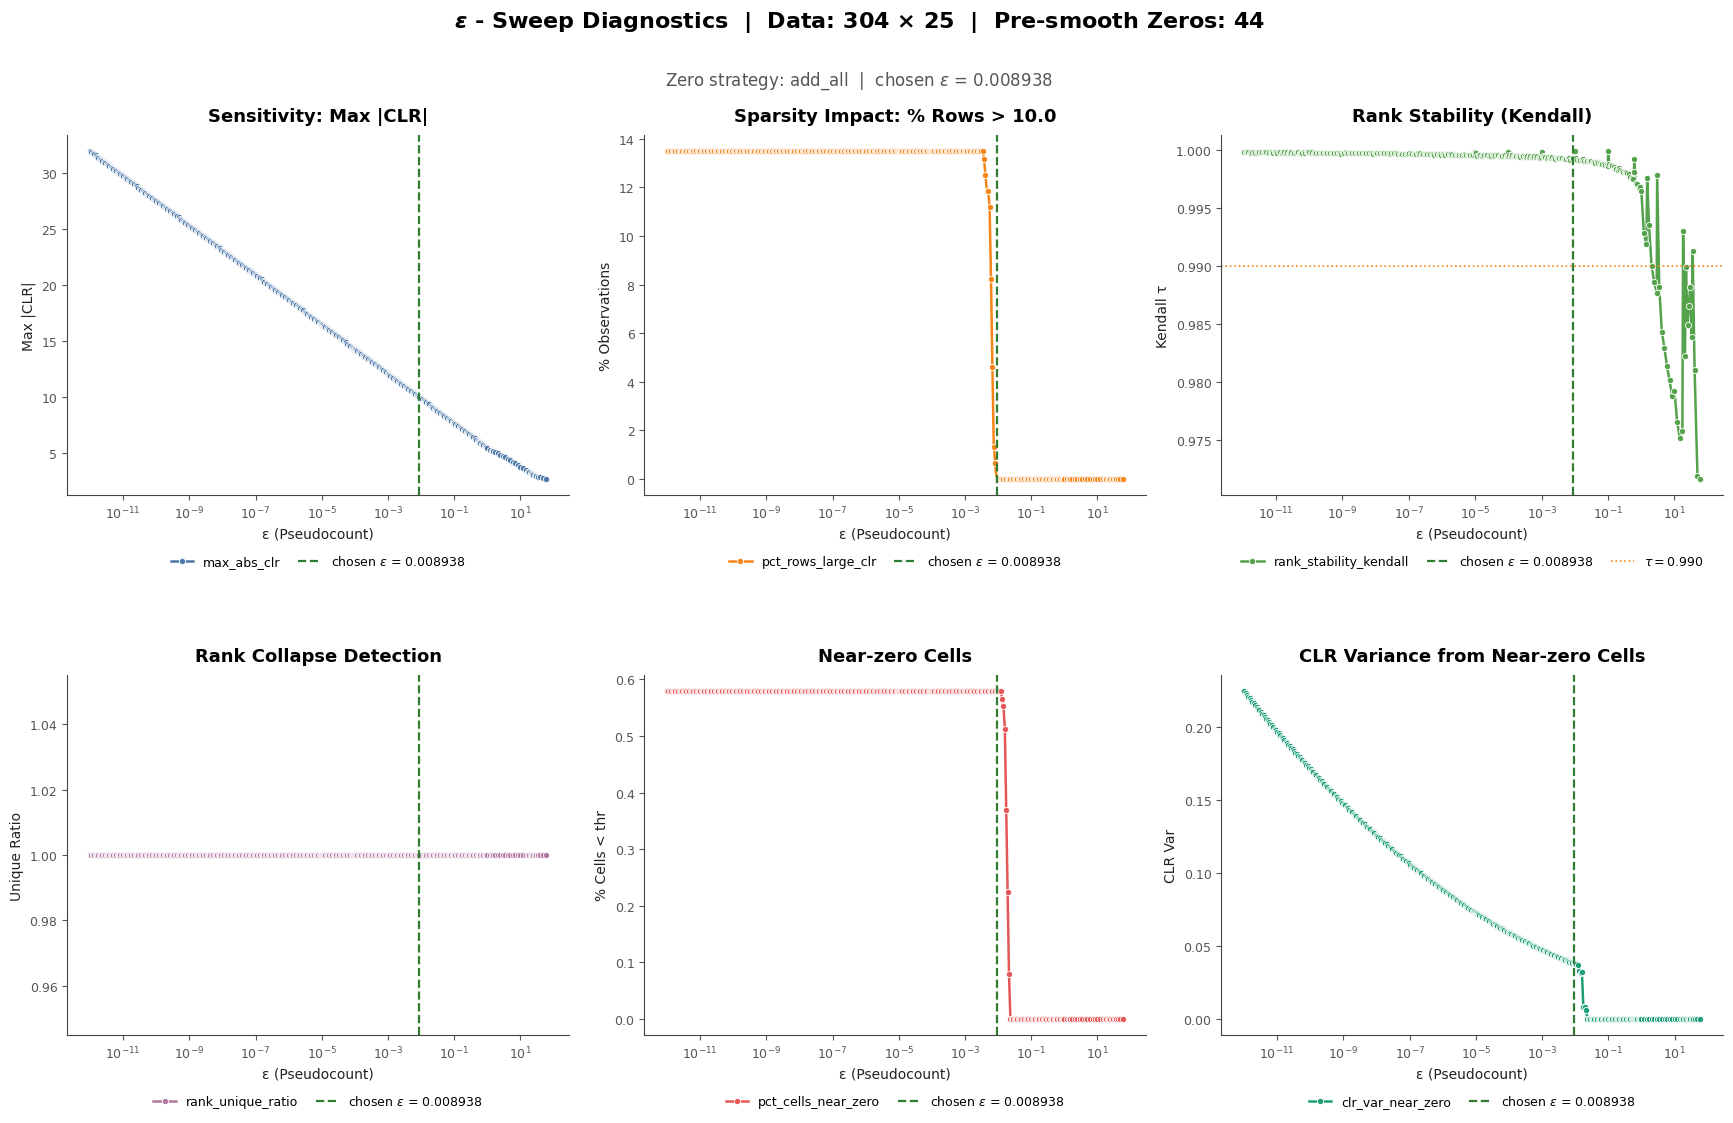

In [13]:
# Find delta constant
epsilon_result = grid.build_eps_grid(fill_results['filled_df'])
# Select Optium esp
epsilon_sweep_result = grid.sweep_epsilon_grid(epsilon_result['pivot_data'], epsilon_result['eps_values'], auto_select=True, plot=True)

In [14]:
# Extracts the transition window 
df_view, chosen_eps, prior_eps = utils.get_epsilon_transition(epsilon_sweep_result, window_prior=5, window_past=5)
df_view

index,status,is_chosen,eps,zero_strategy,max_abs_clr,mean_max_abs_clr,pct_rows_large_clr,rank_stability_spearman,rank_stability_kendall,rank_unique_ratio,rank_entropy,zero_contribution_ratio
236,❌ FALSE,,0.0055228122,add_all,10.435165,5.126980,11.184211,1.000000,0.999258,1.000000,8.247928,0.025383
237,❌ FALSE,,0.0060809597,add_all,10.342752,5.114404,8.223684,1.000000,0.999321,1.000000,8.247928,0.025283
238,❌ FALSE,,0.0066955148,add_all,10.250341,5.101813,4.605263,1.000000,0.999359,1.000000,8.247928,0.025182
239,❌ FALSE,,0.0073721781,add_all,10.157930,5.089206,1.315789,1.000000,0.999169,1.000000,8.247928,0.025080
240,❌ FALSE,,0.0081172265,add_all,10.065522,5.076581,0.657895,1.000000,0.999288,1.000000,8.247928,0.024978
241,✅ TRUE,⭐ [CHOSEN],0.0089375712,add_all,9.973115,5.063935,0.000000,1.000000,0.999344,1.000000,8.247928,0.024876
242,✅ TRUE,,0.0098408216,add_all,9.880709,5.051268,0.000000,1.000000,0.999214,1.000000,8.247928,0.024773
243,✅ TRUE,,0.0100000000,add_all,9.865308,5.049154,0.000000,1.000000,0.999906,1.000000,8.247928,0.024756
244,✅ TRUE,,0.0108353565,add_all,9.788306,5.038577,0.000000,1.000000,0.999339,1.000000,8.247928,0.024670
245,✅ TRUE,,0.0119304013,add_all,9.695904,5.025859,0.000000,1.000000,0.999126,1.000000,8.247928,0.024566


In [15]:
# PCA for CLR: Sparse
pca_result = pca_anchor.compute_pca(epsilon_sweep_result['clr_dict'][chosen_eps], epsilon=chosen_eps)


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0



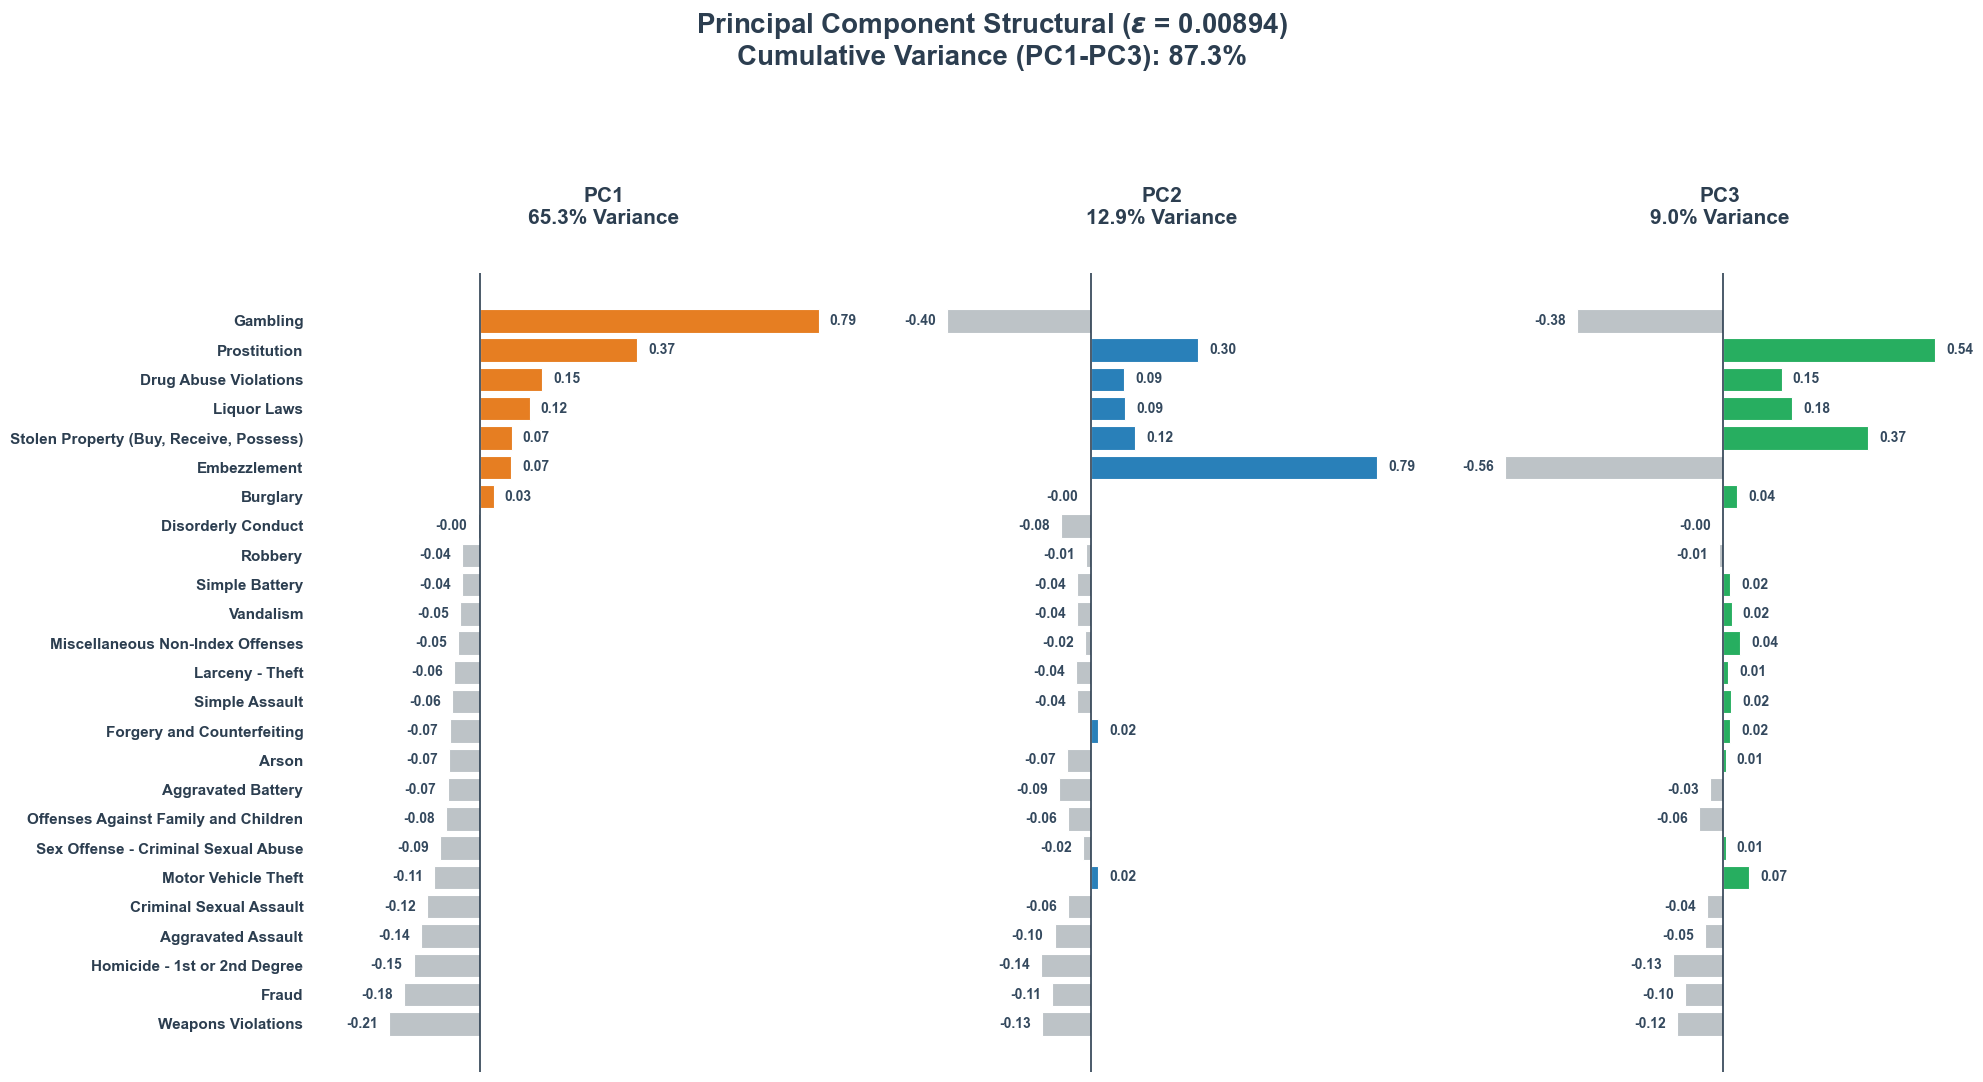

In [16]:
# Plot PCA
three_loadings_result = pca_anchor.plot_three_loadings(pca_result, epsilon=chosen_eps)

#### Gambling

In [17]:
# Copy the aggregated, filled monthly crime data
data = fill_results['filled_df']

# Extract the monthly time series for the crime category "Gambling"
gambling = (data[data['fbi_code_desc'] == 'Gambling']   # filter to Gambling incidents
            .set_index('year_month')['crime_count']     # use year_month as index, select counts
            .sort_index())                              # ensure chronological order

# Basic counts of how often Gambling appears
print(f"Total months for Gambling: {len(gambling)}")          # total months in the series
print(f"Zero months: {(gambling == 0).sum()}")                # months with zero incidents
print(f"Non-zero months: {(gambling > 0).sum()}\n")           # months with >0 incidents

# Identify all months where the gambling count is zero
gambling_zeros = gambling[gambling == 0].index

# Count zero months by calendar year
print(f"Zero months by year:")
zeros_by_year = gambling_zeros.to_series().dt.year.value_counts().sort_index()
print(zeros_by_year.to_string())

# Print every zero month in chronological order
print(f"\nAll zero months (chronologically):")
for d in gambling_zeros:
    print(f"  {d.strftime('%Y-%m')}")

# Yearly summary statistics for Gambling incidents
print(f"\nGambling yearly totals (full series):")
yearly = gambling.groupby(gambling.index.year).agg(['sum', 'mean', 'min', 'max'])
yearly.columns = ['total', 'mean_per_month', 'min', 'max']    # rename columns for clarity
print(yearly.to_string())

Total months for Gambling: 304
Zero months: 28
Non-zero months: 276

Zero months by year:
year_month
2016    1
2020    3
2021    4
2022    7
2023    4
2024    2
2025    4
2026    3

All zero months (chronologically):
  2016-12
  2020-02
  2020-04
  2020-12
  2021-01
  2021-02
  2021-08
  2021-12
  2022-01
  2022-02
  2022-04
  2022-09
  2022-10
  2022-11
  2022-12
  2023-02
  2023-04
  2023-05
  2023-11
  2024-01
  2024-02
  2025-01
  2025-02
  2025-03
  2025-12
  2026-01
  2026-02
  2026-03

Gambling yearly totals (full series):
             total  mean_per_month   min    max
year_month                                     
2001         934.0       77.833333  37.0  109.0
2002         980.0       81.666667  42.0  125.0
2003        1134.0       94.500000  41.0  139.0
2004        1194.0       99.500000  36.0  171.0
2005        1146.0       95.500000  32.0  199.0
2006        1418.0      118.166667  37.0  205.0
2007        1425.0      118.750000  22.0  214.0
2008        1205.0      100.4166

In [18]:
# Confirm the 99% claim directly
peak_window = gambling.loc['2006-01-01':'2008-12-01'].mean()
trough_window = gambling.loc['2020-01-01':'2025-12-01'].mean()
decline = 1 - (trough_window / peak_window)

print(f"Mean monthly count, 2006–2008 (peak window): {peak_window:.1f}")
print(f"Mean monthly count, 2020–2025 (trough window): {trough_window:.2f}")
print(f"Decline from peak window to trough window: {decline:.1%}")

Mean monthly count, 2006–2008 (peak window): 112.4
Mean monthly count, 2020–2025 (trough window): 1.39
Decline from peak window to trough window: 98.8%


| Period | Mean per month | Approximate decline |
|---|---:|---:|
| 2001–2008 (peak era) | 81–118 | Baseline |
| 2009–2012 | 60–83 | Modest decline |
| 2013–2015 | 26–50 | Substantial decline |
| 2016–2019 | 12–17 | Near-collapse |
| 2020 onward | 0.25–2.2 | $\approx$99% reduction from peak |


- 2009: Legislation Passed
    - July 13, 2009: Governor Pat Quinn signed the Video Gaming Act into law. It was introduced to fund a $31 billion state infrastructure improvement plan. The law authorized up to 5 VGTs in licensed retail establishments, truck stops, and veteran/fraternal organizations.
    - October 19, 2009: The Illinois Gaming Board (IGB) issued the initial emergency rules to establish the regulatory framework and licensing processes.
- 2012: VGTs Go Live
    - September 10, 2012: The Central Communications System officially launched, and the first legal VGTs went live for patron play across the state.
- 2019: Major Expansion
    - June 2019: The Illinois Gambling Expansion Bill (Public Act 101-0031) was signed into law. This legislation significantly expanded the Video Gaming Act by:
        - Increasing the maximum number of VGTs allowed in licensed truck stops from 5 to 10.
        - Increasing the maximum number of VGTs allowed in fraternal and veterans establishments from 5 to 10.
        - Raising the maximum tax rate on video gaming net terminal income.
- 2021: Post-Pandemic Adjustments.
    - October 2021: House Bill 3136 was passed, implementing further structural and regulatory updates across the state's gaming laws. This bill refined operational rules for VGTs, licenses, and revenue sharing.
- 2024–2026: Modernization and Regulatory Updates
    - 2024–2025: The IGB continued to propose and draft rule updates regarding cashless wagering, Self-Exclusion Programs, and Sales Agent Licensure to modernize oversight.
    - Ongoing: The network has grown to nearly 50,000 VGTs statewide. However, municipalities (most notably Chicago) retain the local option to prohibit video gaming terminals within their city limits.


**Note:**
> Monthly Gambling counts declined nearly monotonically over the panel, from a peak of 118.8 incidents per month in 2007 to 11.9 in 2019, then a further sharp drop to 1–2 per month from 2020 onward, a 98.8% decline between the peak window (2006-2008, mean 112.4/month) and the trough window (2020-2025, mean 1.4/month). The decline began before the July 13, 2009, enactment of the Illinois Video Gaming Act and continued through the rollout of legal Video Gaming Terminals (first patron play September 10, 2012) and the 2019 Gambling Expansion Bill. Critically, Chicago itself maintained a municipal ban on VGTs throughout the panel period (lifted only in late 2025), so the decline cannot be attributed to legal in-city substitutes for illegal gambling. Plausible contributors include geographic displacement of demand to legal suburban venues, secular de-prioritization of vice enforcement by CPD, and shifts of illegal gambling toward online platforms. Gambling remains in the compositional analysis, but post-2015 CLR values are influenced by the choice of pseudocount and should be interpreted with this in mind.

#### Prostitution

In [19]:
# Extract monthly time series for Prostitution incidents
prost = (data[data['fbi_code_desc'] == 'Prostitution']   # filter to Prostitution cases
         .set_index('year_month')['crime_count']          # use year_month as index, select counts
         .sort_index())                                   # ensure chronological order

# Yearly summary statistics for Prostitution
yearly = prost.groupby(prost.index.year).agg(['sum', 'mean', 'min', 'max'])
yearly.columns = ['total', 'mean_per_month', 'min', 'max']  # rename for clarity
print("Prostitution yearly pattern:")
print(yearly.to_string())

# Compare historical high-activity period vs recent low-activity period
peak = prost.loc['2001-01-01':'2008-12-01'].mean()          # average monthly incidents in early 2000s
trough = prost.loc['2020-01-01':'2025-12-01'].mean()        # average monthly incidents in recent years

print(f"\nPeak window mean (2001–2008): {peak:.1f}/month")
print(f"Trough window mean (2020–2025): {trough:.2f}/month")

# Compute proportional decline if peak is non-zero
if peak > 0:
    print(f"Decline: {(1 - trough/peak):.1%}")

# Identify months with zero reported Prostitution incidents
zeros = prost[prost == 0]
if len(zeros) > 0:
    print(f"\nZero months ({len(zeros)} total):")
    for d in zeros.index:
        print(f"  {d.strftime('%Y-%m')}")


Prostitution yearly pattern:
             total  mean_per_month    min    max
year_month                                      
2001        6026.0      502.166667  423.0  592.0
2002        6408.0      534.000000  437.0  612.0
2003        6214.0      517.833333  415.0  610.0
2004        7476.0      623.000000  400.0  729.0
2005        6124.0      510.333333  367.0  583.0
2006        7034.0      586.166667  404.0  712.0
2007        6087.0      507.250000  327.0  572.0
2008        5141.0      428.416667  290.0  506.0
2009        3940.0      328.333333  242.0  411.0
2010        2484.0      207.000000  172.0  278.0
2011        2424.0      202.000000  136.0  283.0
2012        2204.0      183.666667  111.0  267.0
2013        1652.0      137.666667   43.0  177.0
2014        1625.0      135.416667   69.0  197.0
2015        1322.0      110.166667   64.0  182.0
2016         800.0       66.666667   12.0  113.0
2017         735.0       61.250000   23.0   88.0
2018         718.0       59.833333   20.

**Note:**
- Phase 1: Steady street economy (2001–2008). Arrests averaged 400–630/month. This was the pre-Internet street-prostitution era, when transactions happened in person, in known geographic areas, and police could make arrests through routine patrols and stings.
- Phase 2: The internet took over (2009–2015). Arrests fell from 525/month to $\approx$110/month, roughly an 80% drop. The most likely explanation is that sex work moved online, and online platforms made street solicitation unnecessary. You don't get arrested for a transaction your buyer arranged online, and that happens behind closed doors. The activity didn't disappear, but the visible, arrestable version of it did.
- Phase 3: Legacy enforcement (2016–2019). Arrests settled into $\approx$60/month. This was a new low baseline. Most sex work was online; what remained on the street was either people who couldn't or wouldn't use online platforms, or sting operations against the people still working visibly.
- Phase 4: COVID floor (2020–2025). Arrests collapsed to $\approx$10–25/month. Lockdowns shut down what street activity remained, indoor venues closed, and post-pandemic, the numbers never returned to even the 2019 baseline.

**Legally**
- A few things, none of which is the main driver of the count decline:
    - 2010 - Illinois made minors under 18 immune from prostitution prosecution
    - 2013 - Illinois made prostitution always a misdemeanor (no more felony charges)
    - 2018 - FBI seized Backpage; federal FOSTA-SESTA passed (April 2018)

**The 96% decline in prostitution arrests in Chicago isn't a 96% decline in sex work, but it's a 96% decline in the kind of sex work that's visible to police patrols.**

#### Scaled version as a sensitivity check
Our PC1 loadings (0.79 Gambling, 0.37 Prostitution, then everything else < 0.15) reflect the fact that Gambling has enormous CLR variance; its share collapsed from $\approx$0.5% to $\approx$0.005% of monthly crime over the panel, which is a log-ratio swing of roughly log(100) $\approx$ 4.6 units. Almost no other category moved that much in CLR space. So when we fit PCA on unstandardized CLR, PC1 is essentially "the Gambling axis." That's mathematically correct and substantively defensible, but Gambling really is the category with the most extreme compositional shift. But it means PC1 isn't really a multivariate finding; instead, it's a univariate finding about Gambling, dressed up as a principal component. If you z-score the CLR coordinates first, we would be asking a different question: "What patterns of co-movement exist among the categories, treating each as equally important?" That's a legitimate question too, and the resulting PCs would tell a different story, likely one with less Gambling/Prostitution dominance and more visible signal from the high-volume violent crime categories.

#### Scale Vs. Not
| Situation | Recommendation |
|---|---|
| Following Aitchison's framework strictly | Don't scale. Use CLR + un-standardized PCA. This is the textbook choice. |
| Variance is dominated by 1-2 outlier categories | Run both, compare. We are in this situation. |
| Our downstream analysis is geometric (Aitchison distance, CLR-based tests) | Don't scale. Preserves the geometry. |
| Our goal is "find co-movement clusters," treating each category as equally interesting | Consider scaling, but be aware you've departed from compositional convention. |
| Our goal is to "characterize the largest compositional shifts." | Don't scale. Unstandardized correctly identifies the biggest movers. |

##### Three Versions
| Version | Setup | Purpose |
|---|---|---|
| A - Main analysis | Unstandardized CLR (current code) | Faithful to Aitchison framework |
| B - Scaled sensitivity | Z-scored CLR coordinates | Tests whether findings depend on Gambling/Prostitution dominance |
| C - Excluding vice | Unstandardized CLR, 23 categories (drop Gambling, Prostitution) | Tests robustness to category inclusion |

In [20]:
# Version A: un-standardized CLR (your current approach)
pca_A = pca_anchor.compute_pca(epsilon_sweep_result['clr_dict'][chosen_eps], epsilon=chosen_eps)

# Version B: z-scored CLR
scaler = StandardScaler()
clr_scaled = pd.DataFrame(
    scaler.fit_transform(epsilon_sweep_result['clr_dict'][chosen_eps]),
    columns=epsilon_sweep_result['clr_dict'][chosen_eps].columns,
    index=epsilon_sweep_result['clr_dict'][chosen_eps].index
)
pca_B = pca_anchor.compute_pca(clr_scaled, epsilon=chosen_eps)

# Version C: un-standardized CLR, excluding vice categories
exclude = ['Gambling', 'Prostitution']
clr_matrix = grid.clr_transform(counts=fill_results['filled_df'], epsilon=chosen_eps, exclude_features=exclude, verbose=True)
pca_C = pca_anchor.compute_pca(clr_matrix, epsilon=chosen_eps)


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0

Excluded 2 categories before pivot: ['Gambling', 'Prostitution']
  categories: 25 -> 23
CLR transform [add_all]: 304 × 23
  epsilon          : 0.00893757115105424
  zeros in data    : 14 (0.20% of cells)
  max |CLR|        : 10.1187
  max row-sum error: 4.88e-14

             📊

In [21]:
# Compare variance explained
# Create headers and data format templates
row_fmt = "  {:<16} | {:>8} | {:>18}"
divider = "-" * 50

print(f"\n{ '=== PCA VARIANCE EXPLAINED COMPARISON ===' :^50}")
print(row_fmt.format("Model Version", "PC1 Var", "PC1-3 Cumulative"))
print(divider)

# Version A
print(row_fmt.format(
    "A (Unscaled, 25)", 
    f"{pca_A['variance_ratio'][0]:.1%}", 
    f"{pca_A['variance_ratio'][:3].sum():.1%}"
))

# Version B
print(row_fmt.format(
    "B (Z-scored, 25)", 
    f"{pca_B['variance_ratio'][0]:.1%}", 
    f"{pca_B['variance_ratio'][:3].sum():.1%}"
))

# Version C
print(row_fmt.format(
    "C (Unscaled, 23)", 
    f"{pca_C['variance_ratio'][0]:.1%}", 
    f"{pca_C['variance_ratio'][:3].sum():.1%}"
))
print("=" * 50)


    === PCA VARIANCE EXPLAINED COMPARISON ===     
  Model Version    |  PC1 Var |   PC1-3 Cumulative
--------------------------------------------------
  A (Unscaled, 25) |    65.3% |              87.3%
  B (Z-scored, 25) |    56.7% |              72.2%
  C (Unscaled, 23) |    47.1% |              83.0%


#### Three-Way PCA Comparison:

**Setup.** PCA on CLR-transformed monthly Chicago crime composition, run three ways to test whether the dominant variance structure depends on the two declining vice categories (Gambling, Prostitution).

| Version | Specification | PC1 | PC1–3 |
|---|---|---|---|
| A | Un-scaled CLR, 25 categories | 65.3% | 87.3% |
| B | Z-scored CLR, 25 categories | 56.7% | 72.2% |
| C | Un-scaled CLR, 23 categories (no vice) | 47.1% | 83.0% |

**Finding 1 - Vice contributes about a third of the leading axis.** Removing Gambling and Prostitution drops PC1 from 65.3% to 47.1%, an $\approx$18-point reduction. The two vice categories are major contributors to the dominant compositional axis.

**Finding 2 - But the co-movement is not an artifact of vice.** PC1 remains dominant at 47.1% even without the vice categories. A strong co-movement structure exists among the other 23 categories independently.

**Finding 3 - Nor is it a variance-magnitude artifact.** Z-scoring (which removes the magnitude advantage of high-variance categories) only reduces PC1 to 56.7% and is less than removing vice. If the dominance were purely a magnitude effect, z-scoring would have collapsed it, and it didn't, so the co-movement is genuine.

**Finding 4 - The headline variance number is specification-dependent.** "PC1 explains X% of variance" is 65% with vice, 47% without. Both are correct while answering slightly different questions. 

> - For "which crimes move together": Chicago crime categories exhibit strong co-movement (PC1 explains 47–65% of the variance across specifications). Gambling and Prostitution co-move most strongly and drive roughly a third of the leading axis, but a dominant co-movement structure persists among the remaining categories.
> - > The 23-cat `max |CLR|` is **10.12**, slightly *higher* than your 25-cat sweep value of $\approx$9.97. This was expected, but removing the two vice categories changed the geometric-mean denominator, which shifted every remaining CLR coordinate. It's small and harmless, but worth knowing: **our $\varepsilon = 0.00894$ was optimized for the 25-cat panel, and the 23-cat panel runs slightly higher (10.12 vs 9.97)** while holding $\varepsilon$ fixed across both analyses for comparability, and confirmed the sub-composition remained numerically stable (max|CLR| = 10.12).



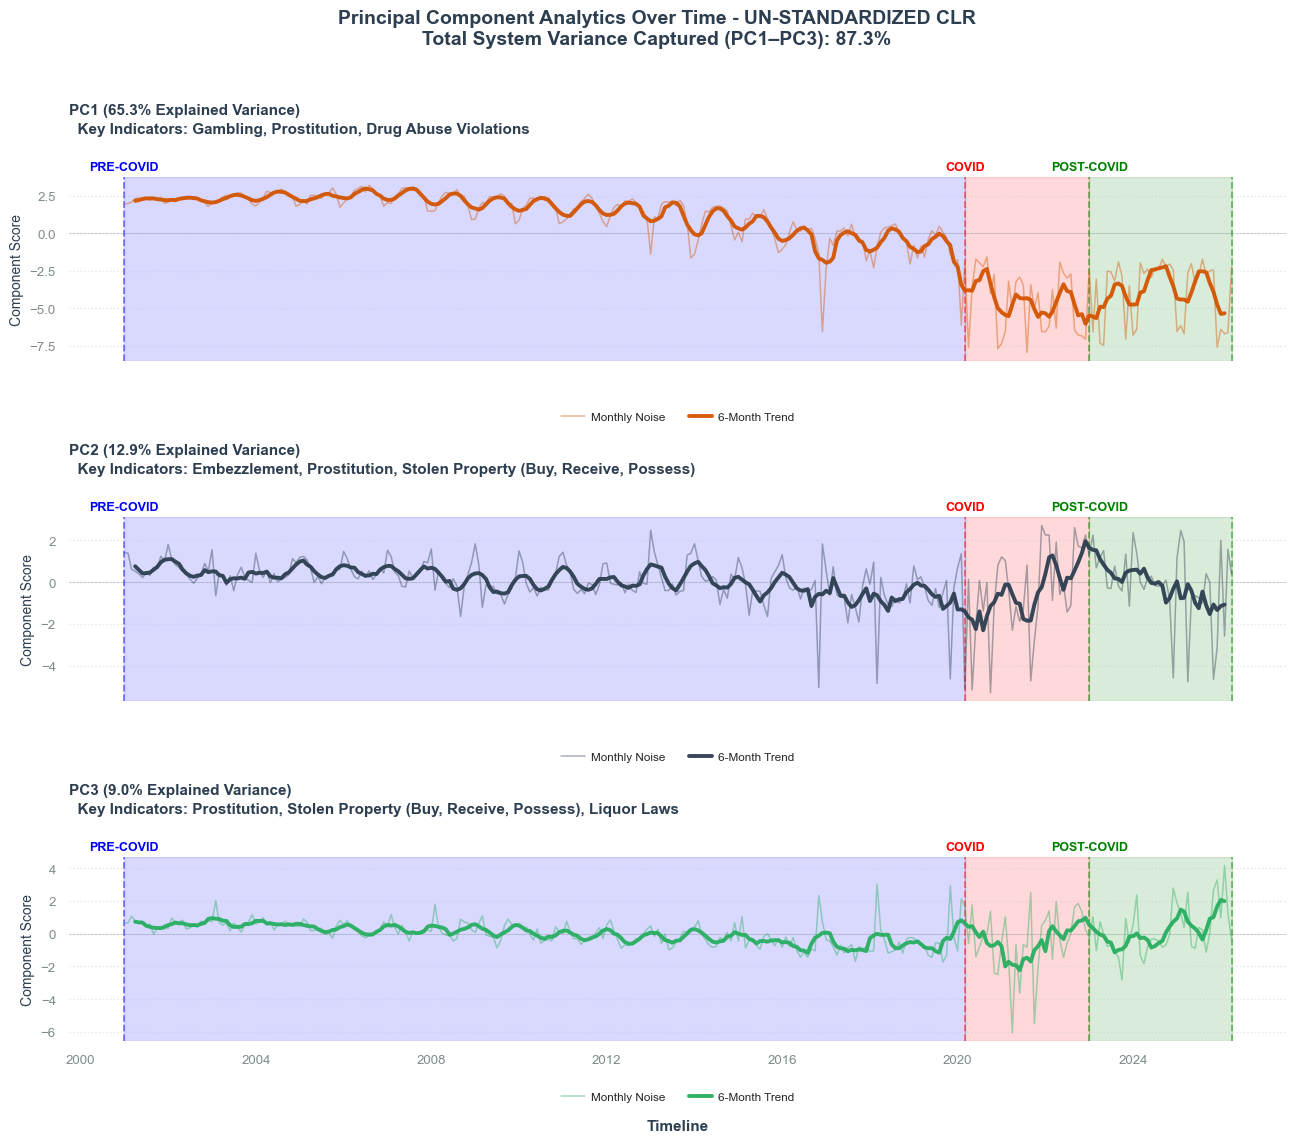

In [22]:
result_A_plot = plot.plot_pc_scores_over_time(pca_dict=pca_A,
                         panel_index=pca_A['observation_index'], 
                         title_suffix=' - Un-standardized CLR')

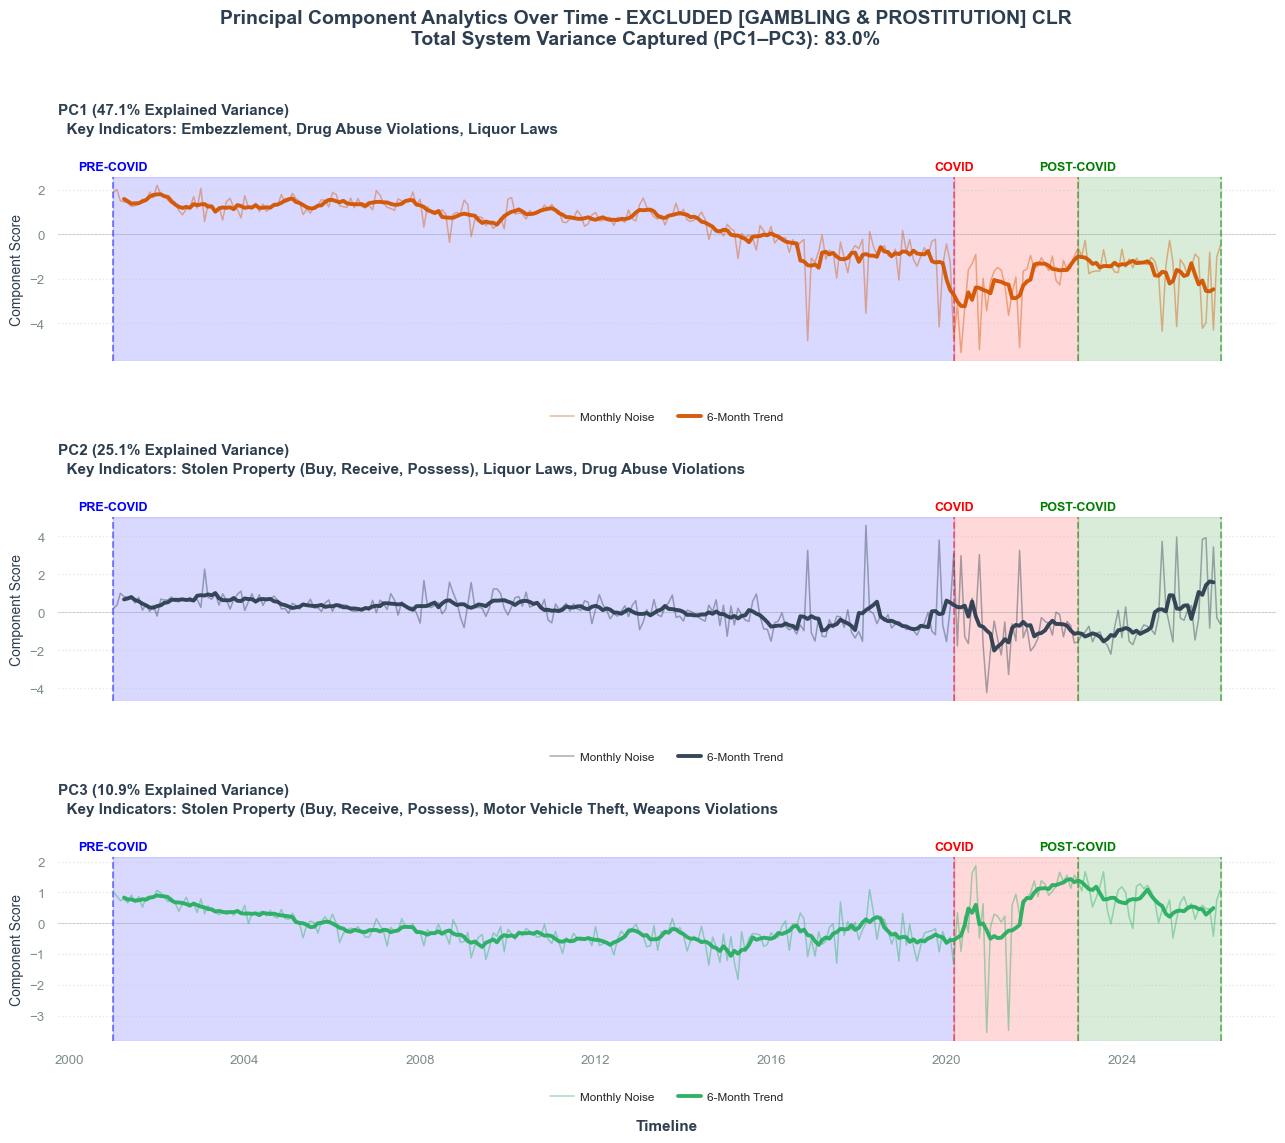

In [23]:
result_C_plot = plot.plot_pc_scores_over_time(pca_dict=pca_C,
                         panel_index=pca_A['observation_index'], 
                         title_suffix=' - excluded [Gambling & Prostitution] CLR')

#### 📌 Summary
> Across both versions of the dataset with and without vice-related categories, the principal components reveal a consistent pattern of structural change in Chicago's crime composition over time. In both analyses, PC1 exhibits a gradual pre-COVID decline followed by a visually pronounced break at the onset of the COVID era around March 2020, a pattern consistent with a structural discontinuity rather than a continuation of prior trends (formal changepoint testing is reported below). In the vice-removed analysis, PC3 provides a distinct COVID-aligned signal: relatively stable or declining before 2020, rising during the pandemic period, then partially reverting. Its dominant loadings on Stolen Property, Motor Vehicle Theft, and Weapons Violations point to a shift in the relative weight of these property and weapons offenses during the COVID era. The post-COVID period also shows evidence of lasting compositional change: in the vice-removed analysis, PC2 rises substantially from around 2022 and remains elevated, indeed still rising through the end of the series, indicating that the composition has not reverted to its pre-COVID structure. Together, the trajectories suggest three distinguishable compositional phases: a long-term pre-COVID decline, a sharp COVID-era disruption, and a post-COVID state that settles at a new compositional configuration rather than returning to historical patterns. Because the analysis is based on CLR-transformed data, the principal component scores reflect changes in relative compositional structure rather than changes in absolute crime levels.

### PCA Stability Diagnostic

In [24]:
# Iniutilize Alternative epsilon
epsilon_compare = [chosen_eps, prior_eps]
# Initialize Dictionary for outputs keyed by epsilon
results_pca = {}

# Loop over selected epsilon values and collect PC‑loading plots
for eps in epsilon_compare:

    # Generate the three‑PC loading plots for this epsilon
    r = pca_anchor.compute_pca(
        epsilon_sweep_result['clr_dict'][eps],
        epsilon=eps, verbose=True
    )

    # Store the result keyed by epsilon
    results_pca[eps] = r


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0


             📊 PCA DATA MANIFEST (ε = 0.00812)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0



#### 📌 Summary

> For the dense subset, $\varepsilon = 0.008936$ was chosen as the smallest pseudocount that removed excessively large CLR values while still preserving rank stability. To test whether this choice was fragile, we compared it with the next lower value in the grid ($\varepsilon = 0.008117$). The PCA results were essentially identical across the boundary: PC1–PC3 matched almost perfectly (cosine similarity $\approx 1.0$), and the shared subspace rotated by only $0.29^\circ$. This shows that the analysis is stable and does not depend on the exact pseudocount selected near this threshold.

### Build Consensus

#### Aitchison Plot for the chosen epsilon

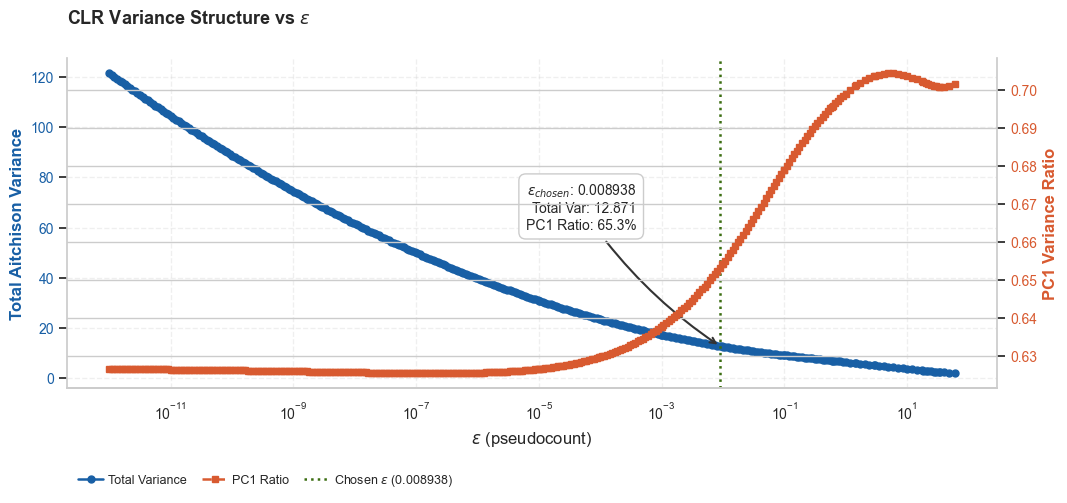

In [25]:
# Aitchison plot for the chosen epsilon (sweep_epsilon_grid() output dictionary:['clr_dict'])
aitchison_results = plot.plot_aitchison(epsilon_sweep_result['clr_dict'], chosen_eps)

#### Stability Diagnostics

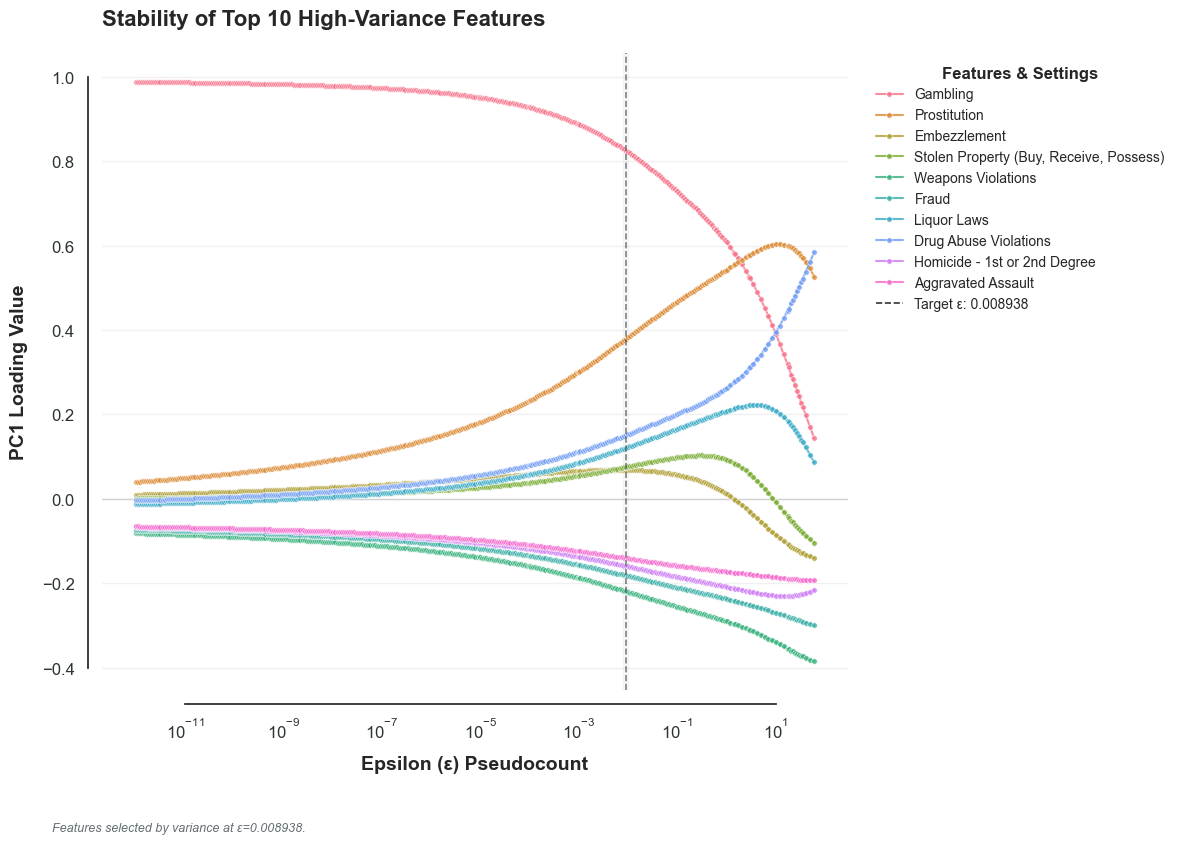

In [26]:
# PC Loading Stability Plot for the chosen epsilon for all
pc1_stability_results = plot.plot_pc1_loading_stability(epsilon_sweep_result['clr_dict'], chosen_eps=chosen_eps, top_k=10)

#### 📌 Summary

> Both PCA plots support the same overall conclusion and show that the selected pseudocount value ($\varepsilon = 0.008938$) produces meaningful and reliable results. The analysis shows that vice-related crimes—especially Gambling and Prostitution are the main drivers behind the first principal component (PC1), which explains about 65% of the overall variation in the crime composition data. When those vice categories are removed, the influence of PC1 drops noticeably to about 47%, confirming that they strongly shape the original pattern. The chosen $\varepsilon$ value is reasonable and avoids unstable or distorted behavior. One important note is that the exact percentages and category weights shift somewhat as $\varepsilon$ changes, so the specific numbers should be viewed as approximate rather than exact. Even so, the overall findings remain consistent: vice-related offenses dominate the original compositional structure. The vice-excluded specification serves as a robustness check, confirming that substantial co-movement structure persists even in the absence of these categories (PC1 $\approx$ 47%). The full 25-category analysis remains the primary specification, with the vice-excluded version providing a complementary check on the robustness of the findings.

## Inspect the CLR Dictionary Structure

In [27]:
# Inspect CLR dict structure
clr_dict = epsilon_sweep_result['clr_dict']
chosen_epsilon = chosen_eps

# Top-Level Diagnostics
print(f"\n📁 CLR DICTIONARY METADATA")
print("═" * 120)
print(f"Type:         {type(clr_dict)}")
print(f"Total Keys:   {len(clr_dict)}")

# Format keys to 6 decimal places for display
formatted_keys = [f"{float(k):.15f}" for k in list(clr_dict.keys())[:5]]
print(f"Keys (Head):  {formatted_keys} ...")


# Targeted Epsilon Drill-down
if chosen_epsilon in clr_dict:
    chosen_clr = clr_dict[chosen_epsilon]
    print(f"\n🔍 DRILL-DOWN: EPSILON = {chosen_epsilon:.15f}")
    print("═" * 120)
    print(f"Matrix Type:   {type(chosen_clr)}")
    print(f"Matrix Shape:  {chosen_clr.shape}")
    print(f"Total Columns: {len(chosen_clr.columns)}")
    
    # Format DatetimeIndex to YYYY-MM
    formatted_index = chosen_clr.index[:5].strftime('%Y-%m').tolist()
    print(f"Index (Head):  {formatted_index} ...")
    print(f"Columns (Head):{chosen_clr.columns[:5].tolist()} ...")
else:
    print(f"[ERROR] Epsilon {chosen_epsilon:.15f} is missing from the dictionary keys.")


📁 CLR DICTIONARY METADATA
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Type:         <class 'dict'>
Total Keys:   323
Keys (Head):  ['0.000000000001000', '0.000000000001101', '0.000000000001212', '0.000000000001335', '0.000000000001470'] ...

🔍 DRILL-DOWN: EPSILON = 0.008937571151054
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Matrix Type:   <class 'pandas.core.frame.DataFrame'>
Matrix Shape:  (304, 25)
Total Columns: 25
Index (Head):  ['2001-01', '2001-02', '2001-03', '2001-04', '2001-05'] ...
Columns (Head):['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault'] ...


### Build the CLR Matrix & Slice Into Eras

In [28]:
# Build CLR Matrix into Eras
clr_era = clr.slice_clr_into_eras(epsilon_sweep_result['clr_dict'], cfg.era_boundaries, eps=chosen_eps)


 📅  CLR TEMPORAL SEGMENTATION REPORT (ε = 0.00893757115105)
  • Total Matrix       : 304 months x 25 crimes
  • Date Horizon       : 2001-01 to 2026-04
------------------------------------------------------------
  Era Label          | Span (T)     | Date Range          
------------------------------------------------------------
  Pre-COVID          | 230 months   | 2001-01 to 2020-02
  COVID              | 34 months    | 2020-03 to 2022-12
  Post-COVID         | 40 months    | 2023-01 to 2026-04



### Compute Per-Era Distributional Parameters

In [29]:
# Compute Per-Era Distribution
eras_stat = clr.compute_era_distribution_parameters(clr_era, verbose=True)


MEAN CLR VECTOR PER ERA
                                         Pre-COVID   COVID  Post-COVID  COVID_minus_Pre-COVID  Post-COVID_minus_Pre-COVID  Post-COVID_minus_COVID
Aggravated Assault                          0.3776  1.3350      1.2376                 0.9574                      0.8600                 -0.0974
Aggravated Battery                          0.8448  1.4718      1.2893                 0.6270                      0.4445                 -0.1825
Arson                                      -1.9626 -1.2915     -1.5687                 0.6711                      0.3939                 -0.2772
Burglary                                    1.5947  1.3982      1.1890                -0.1964                     -0.4057                 -0.2092
Criminal Sexual Assault                    -0.7777 -0.0898     -0.1368                 0.6879                      0.6409                 -0.0470
Disorderly Conduct                         -0.1843 -0.5079     -0.2071                -0.3237      

#### 📌 Summary

> - The per-era analysis shows that Chicago's crime composition changed substantially between the pre-COVID, COVID, and post-COVID periods. The largest and most permanent shifts involved vice-related offenses. Gambling and Prostitution declined sharply during COVID and remained far below their pre-pandemic levels afterward, making them the strongest structural changes in the dataset. At the same time, violent and weapons-related offenses became relatively more prominent during the COVID era, including increases in Weapons Violations, Homicide, and Aggravated Assault. Some of these increases eased after COVID, but they did not fully return to earlier patterns. Motor Vehicle Theft showed the clearest long-term increase, rising steadily across all three periods without reversing. Fraud also increased during COVID, while Drug Abuse Violations declined.
> - The analysis also found that the COVID period was much more unstable and volatile than the years before or after it, especially for lower-frequency categories such as Gambling, Prostitution, Embezzlement, and Stolen Property. Most of this instability settled down after COVID, although Embezzlement remained unusually volatile compared with earlier years. Importantly, the study measures changes in the relative composition of crime categories rather than raw crime totals, meaning the results describe how the balance of offenses shifted within the overall crime system.
> - Overall, the findings point to three characteristically different periods: a relatively stable pre-COVID period, a sharp COVID-era disruption, and a post-COVID period that settled into a new structure rather than returning to the old one.

### Sanity Check
`era_covs_lw`: LW takes your noisy estimated relationships between crime types and asks, "How much of this is real signal vs. sampling noise?" It preserves the signal and reduces noise toward zero.

In [30]:
# Configuration for Audit Report (Sanity Check)
audit_config = {
    'era_covs': "Covariance Matrix Geometry",
    'era_means': "Era Mean Matrix Structure",
    'era_stds': "Era Std Deviation Matrix Structure"
}

width = 65
row_fmt = "  {:<35} | {:>22}"
divider = "─" * width

print("═" * width)
print(f"{'📋 DATA METRIC AUDIT REPORT':^{width}}")
print(f"{'Structural Dimensionality & Sanity Check':^{width}}")
print("═" * width)
print(row_fmt.format("Report Target / Node", "Dimensions"))
print(divider)

for key, title in audit_config.items():
    data = eras_stat.get(key)
    if data is None:
        continue

    # Section Header
    print(f"\n🔹 {title.upper()}")

    # Case A: Nested Era-Specific Covariance Dictionaries
    if isinstance(data, dict):
        items = list(data.items())
        for idx, (era, matrix) in enumerate(items):
            branch = "└── " if idx == len(items) - 1 else "├── "
            dim_str = f"{matrix.shape[0]} × {matrix.shape[1]} (Square)"
            print(row_fmt.format(f"{branch}{era}", dim_str))

    # Case B: Integrated DataFrames
    elif hasattr(data, 'shape'):
        rows, cols = data.shape
        print(row_fmt.format("├── Integrated Dataset", f"{rows} × {cols}"))
        print(row_fmt.format("├── Analyzed Features", f"{rows} Crime Categories"))
        print(row_fmt.format("└── Temporal Breakdown", "3 Eras + 3 Shift Metrics"))

    print(divider)

═════════════════════════════════════════════════════════════════
                   📋 DATA METRIC AUDIT REPORT                    
            Structural Dimensionality & Sanity Check             
═════════════════════════════════════════════════════════════════
  Report Target / Node                |             Dimensions
─────────────────────────────────────────────────────────────────

🔹 COVARIANCE MATRIX GEOMETRY
  ├── Pre-COVID                       |       25 × 25 (Square)
  ├── COVID                           |       25 × 25 (Square)
  └── Post-COVID                      |       25 × 25 (Square)
─────────────────────────────────────────────────────────────────

🔹 ERA MEAN MATRIX STRUCTURE
  ├── Integrated Dataset              |                 25 × 6
  ├── Analyzed Features               |    25 Crime Categories
  └── Temporal Breakdown              | 3 Eras + 3 Shift Metrics
─────────────────────────────────────────────────────────────────

🔹 ERA STD DEVIATION MATRIX STRUCTUR

## Visualize the Mean/Volatility CLR Shift Heatmap

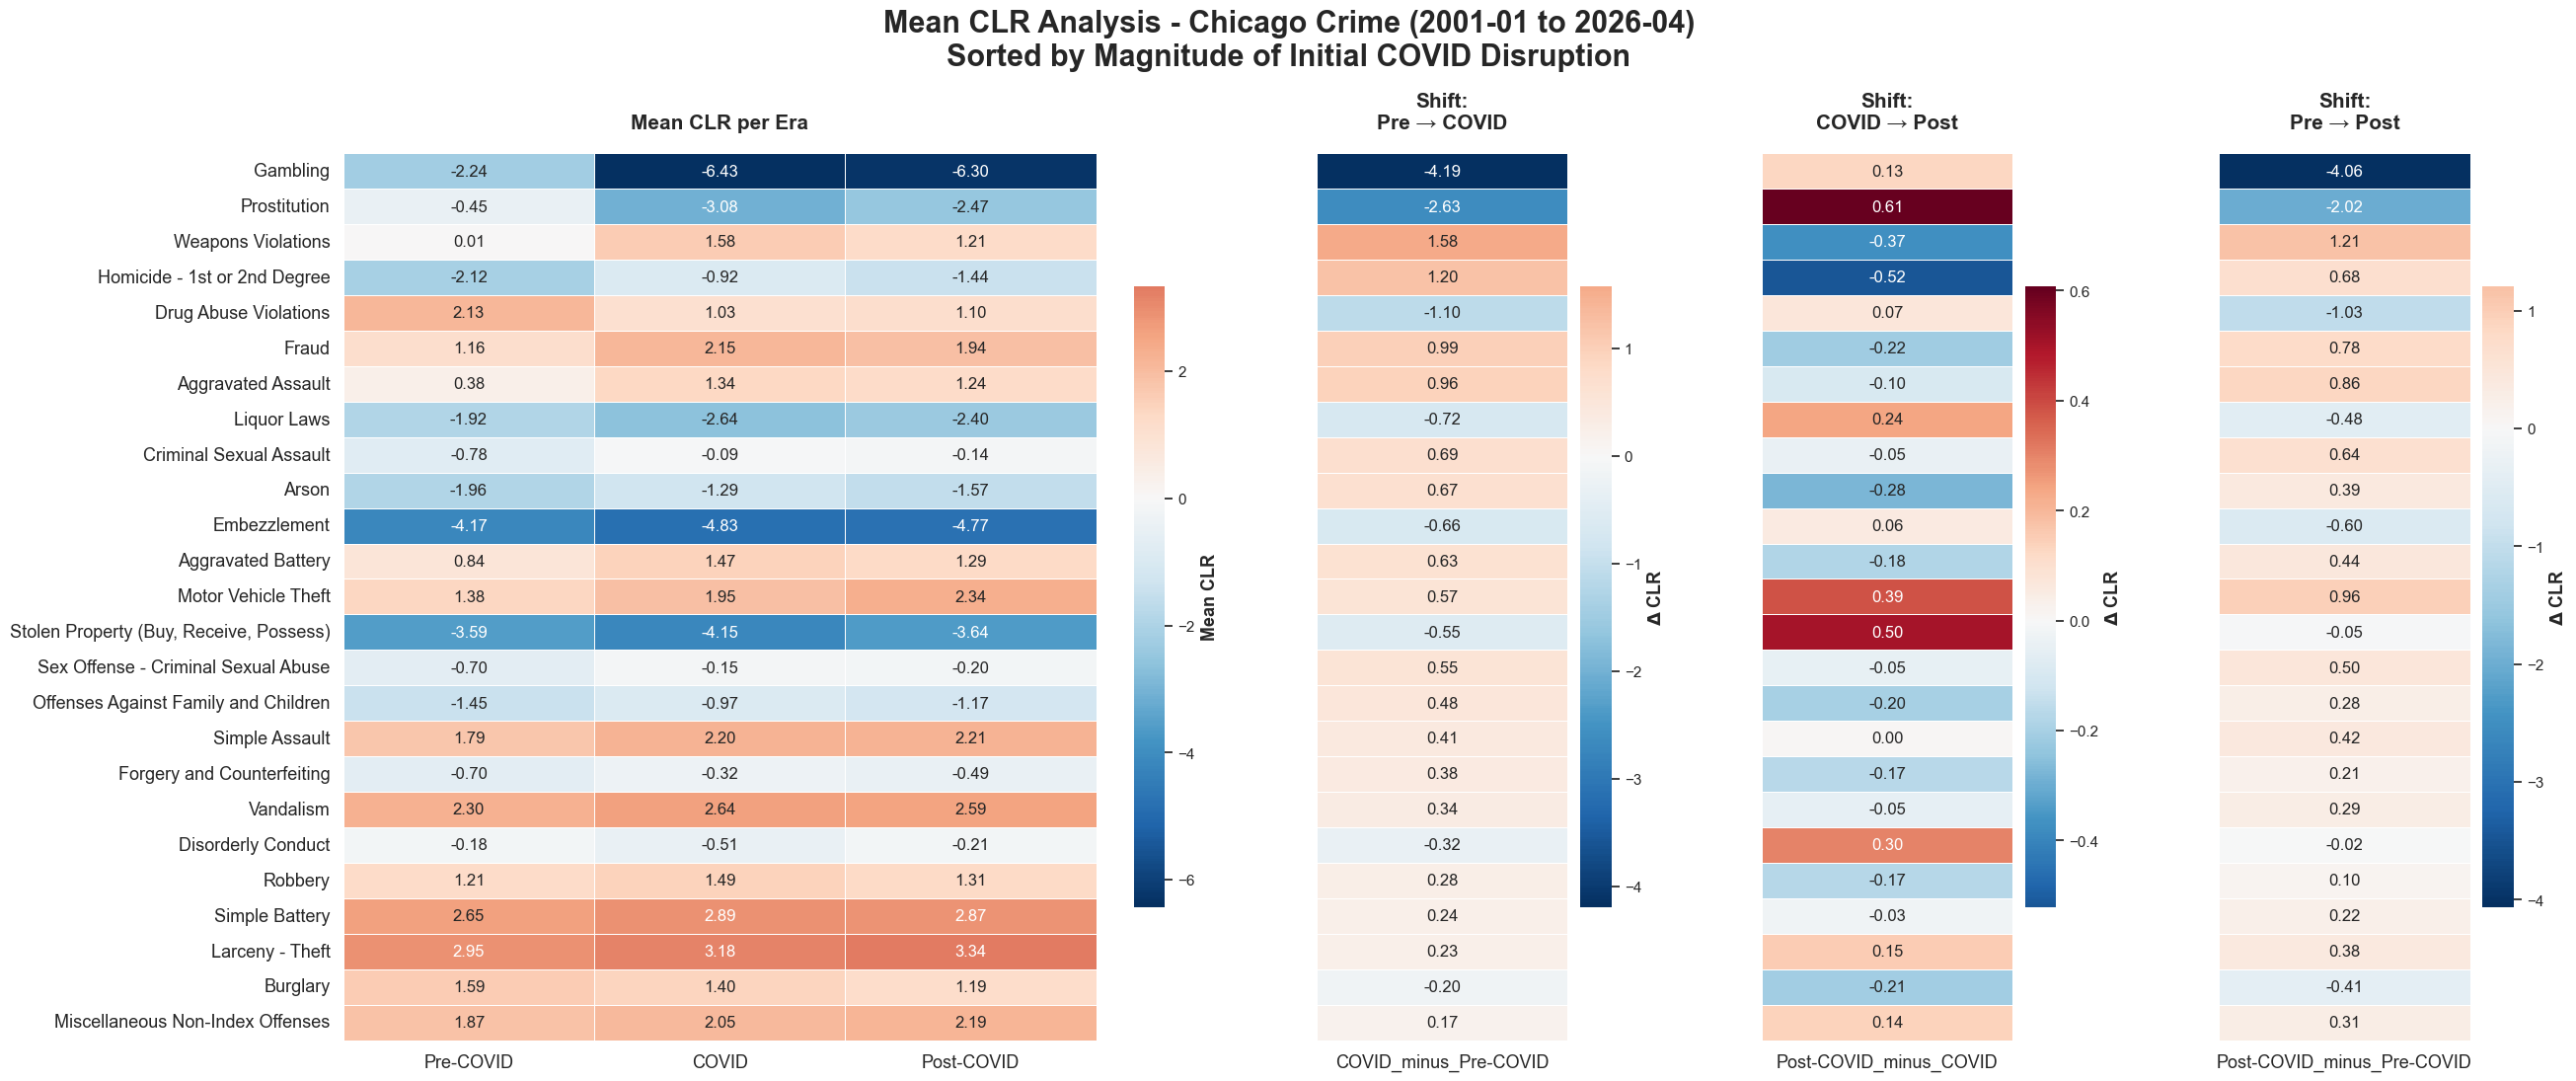

In [31]:
# Heat Map for Mean
plot.plot_era_heatmaps(eras_stat, stat_type='mean')

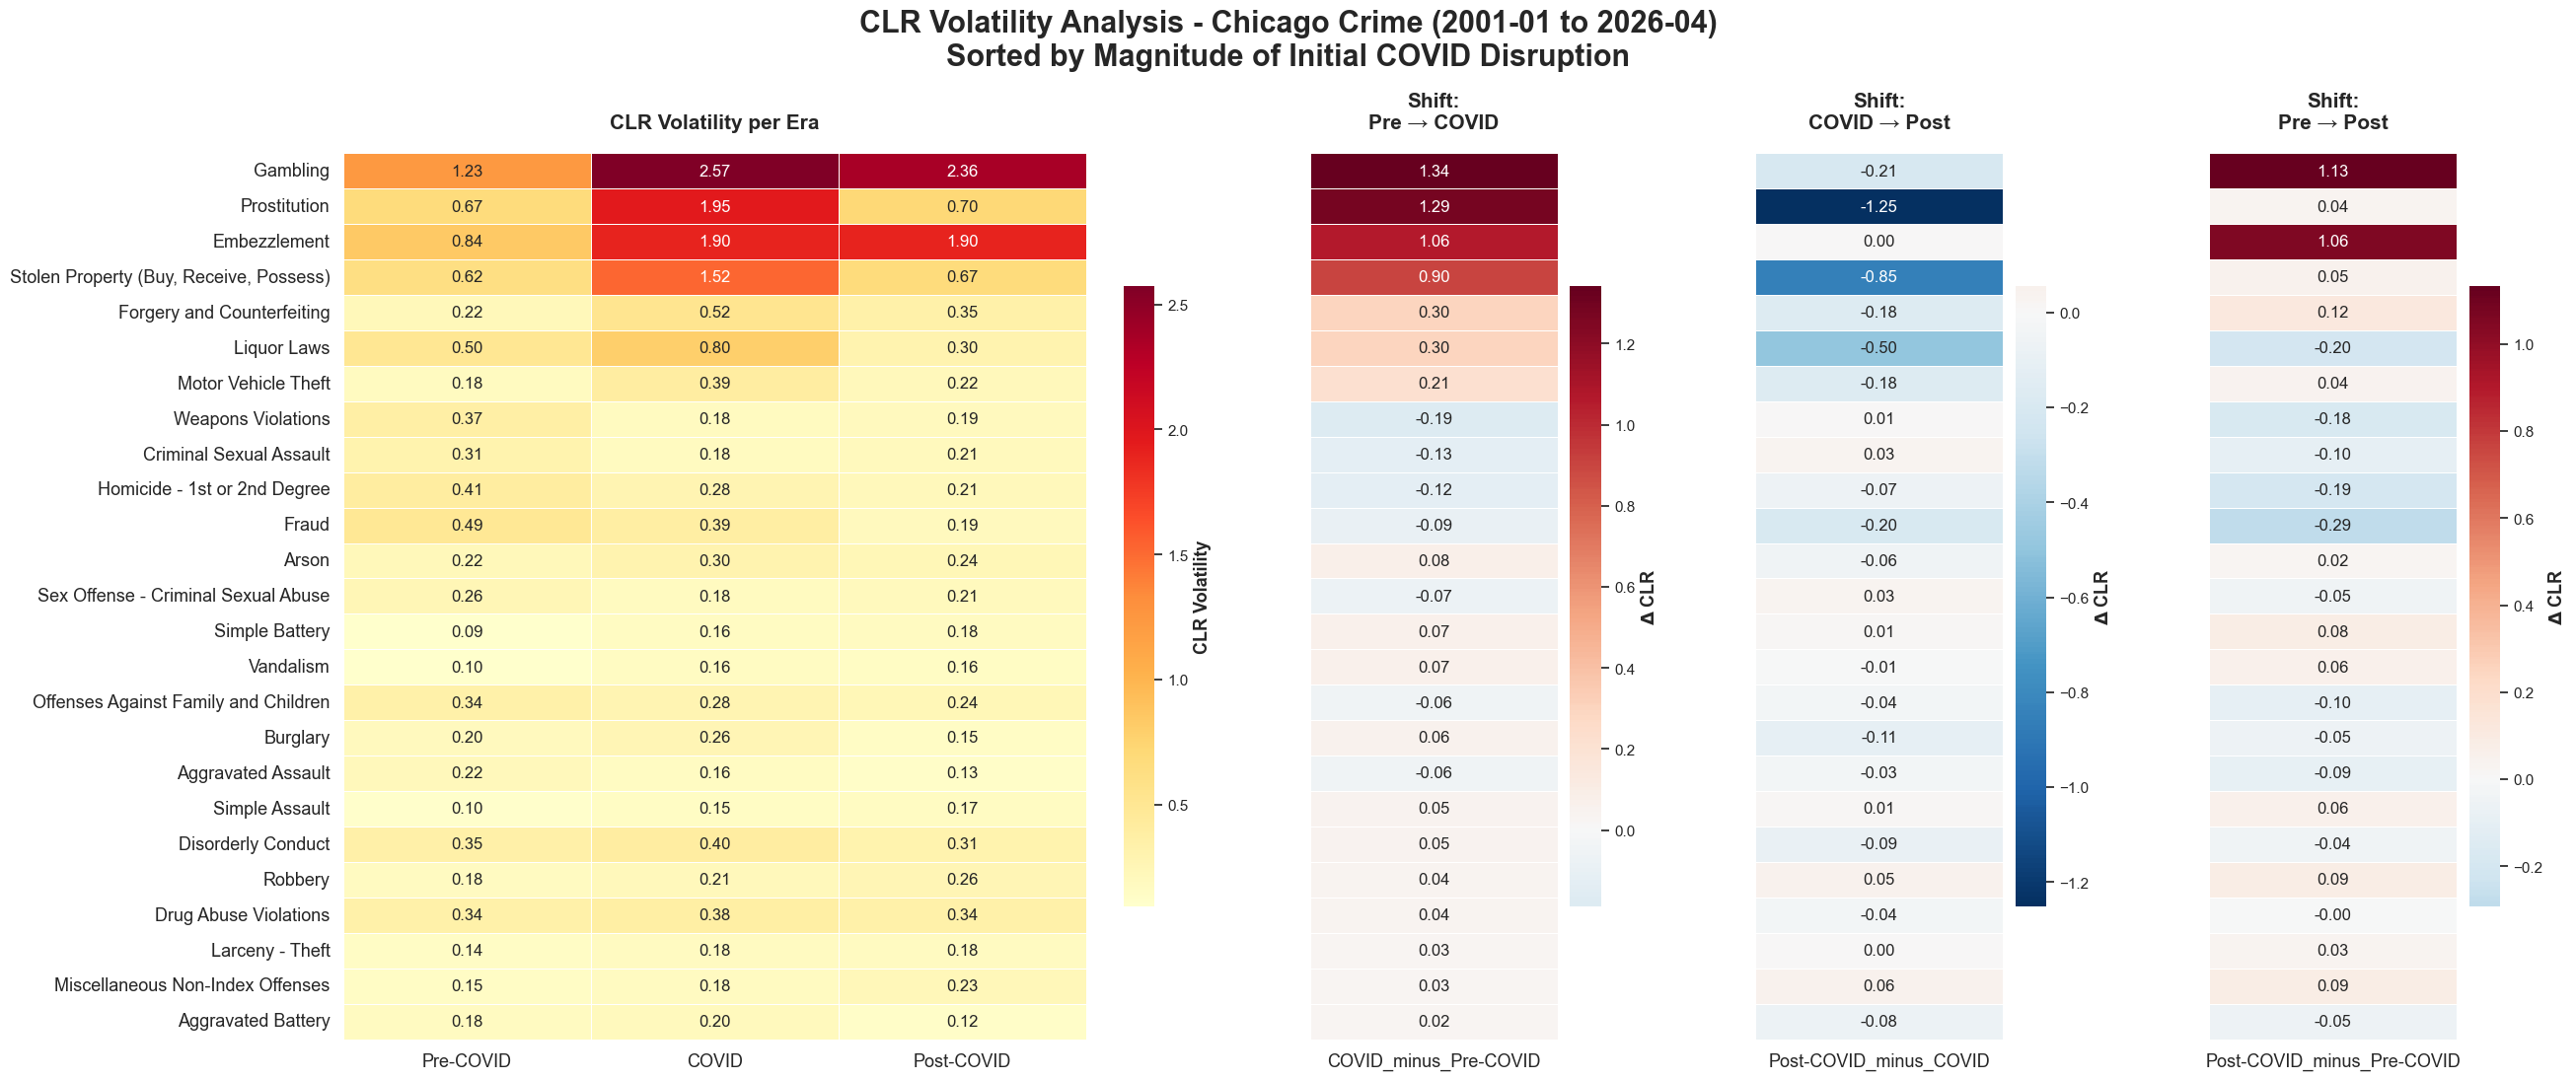

In [32]:
# Heat Map for Volatility
plot.plot_era_heatmaps(eras_stat, stat_type='std')

#### 📌 Summary

> - The mean and volatility heatmaps show that the COVID-era disruption was not evenly spread across all crime categories. Instead, the largest compositional changes were concentrated in four areas: Gambling, Prostitution, Embezzlement, and Stolen Property. These categories experienced much larger shifts than the rest of the system, creating a clear separation between the most disrupted offenses and all others. 
> - The volatility results also show that much of the instability observed during COVID later subsided, especially for Prostitution and Stolen Property, which moved closer to their pre-COVID behavior after the pandemic. Embezzlement, however, remained unusually volatile even after COVID, making it a notable exception.
> - The mean-shift results further show that the post-COVID period did not simply return to pre-pandemic conditions. Property-related offenses, especially Motor Vehicle Theft and Stolen Property, became relatively more prominent after COVID, while some of the sharp COVID-era increases in vice and weapons-related categories partially reversed. Together, these patterns suggest that Chicago entered a new post-COVID crime composition rather than returning to its earlier structure.

### Build & Check the CLR Matrix & Slice Into Eras

In [33]:
# Combined structural audit of CLR‑era matrices and the reconstructed wide‑format dataset
clr_df, raw_wide = utils.audit_clr_and_wide(clr_era = clr_era, fill_results=fill_results)

════════════════════════════════════════════════════════════════════════════════
                        📊 SYSTEM INTEGRITY AUDIT REPORT                         
               Structural Dimensionality & Alignment Verification               
════════════════════════════════════════════════════════════════════════════════
  Inspection Target Node                 |        Properties / Shapes
────────────────────────────────────────────────────────────────────────────────
 [ DATA MATRIX DIMENSIONALITY ]
    ├── Reconstructed CLR Space          |         304 Rows × 25 Cols
    └── Reference Filled Long Space      |        7,600 Rows × 5 Cols
────────────────────────────────────────────────────────────────────────────────
 [ TEMPORAL TIMELINE BOUNDARIES ]
    ├── Timeline Head (Start Window)     | ['2001-01', '2001-02', '2001-03'] …
    └── Timeline Tail (End Window)       | … ['2026-02', '2026-03', '2026-04']
────────────────────────────────────────────────────────────────────────────────

### Per-Category CLR Structural Distribution Plots

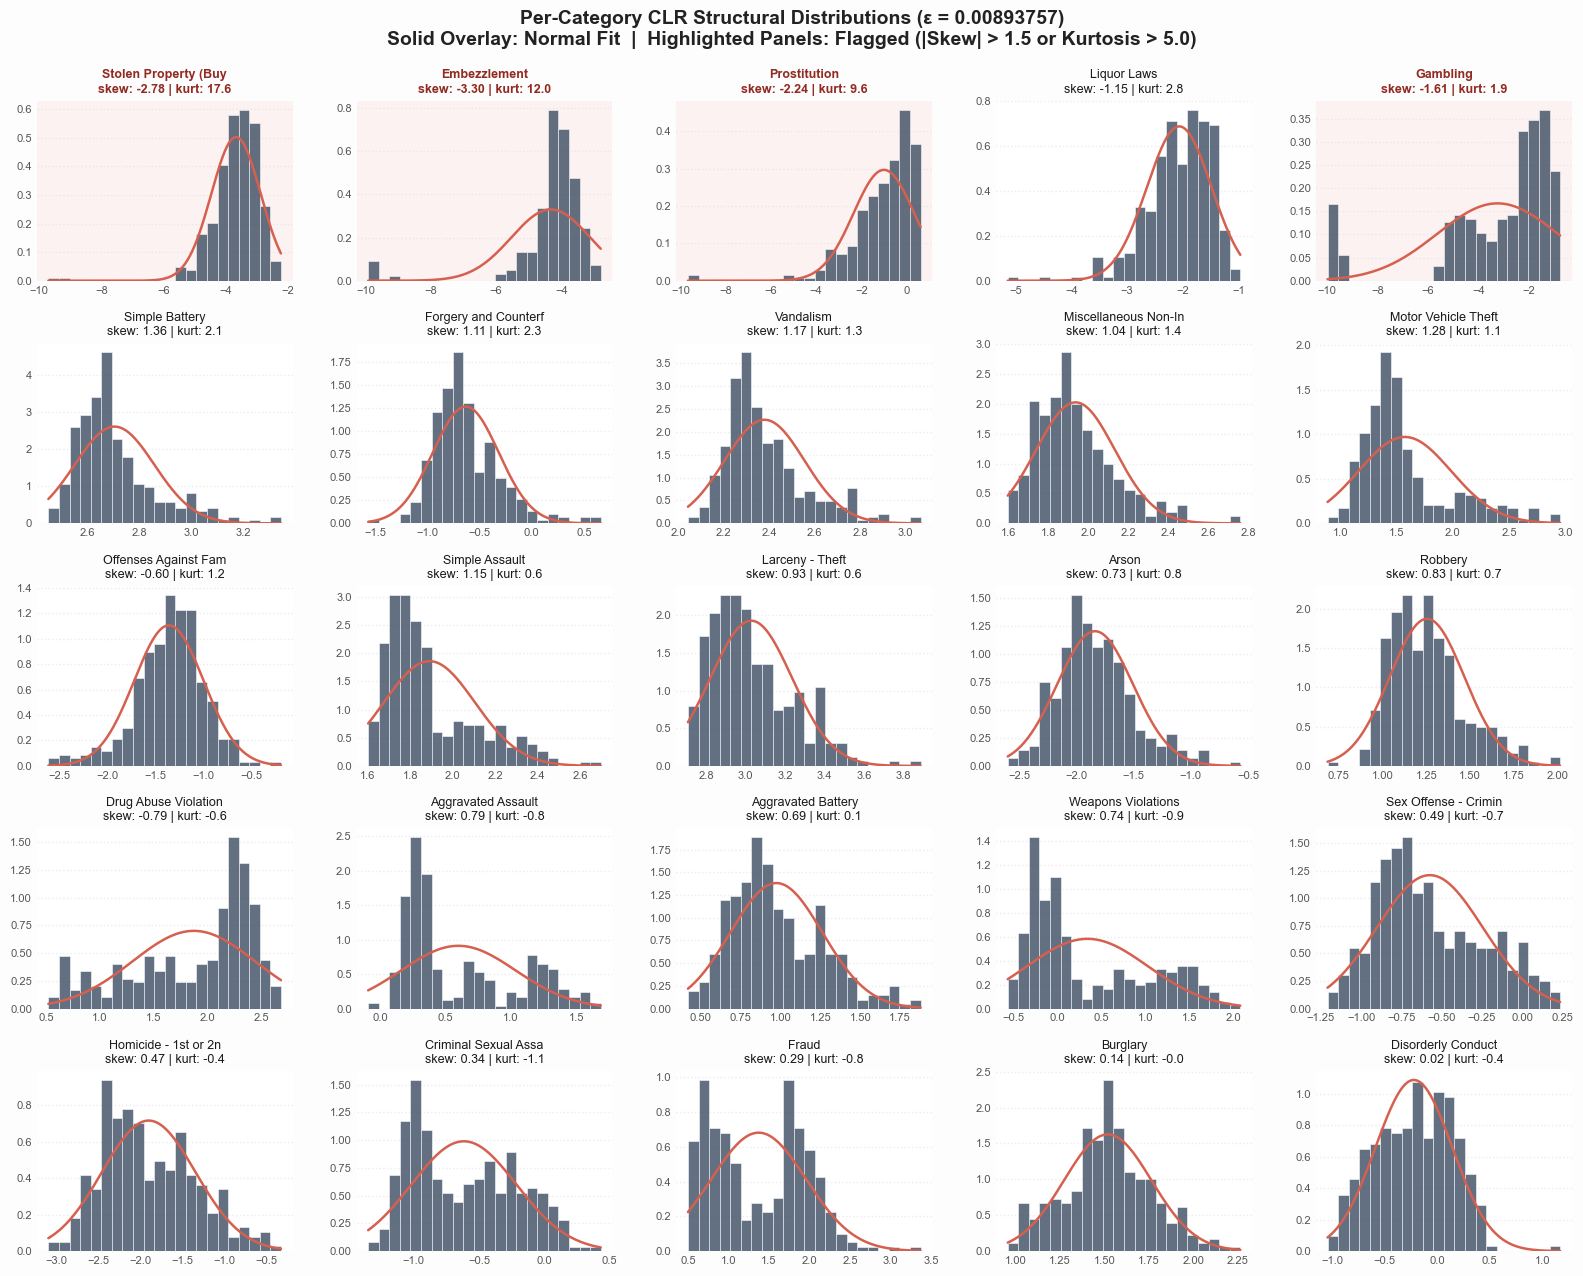

In [34]:
# Perform an optimized per‑category distribution audit on a CLR‑transformed dataset
diag_result = plot.check_clr_distributions(clr_df=clr_df, raw_counts=fill_results['filled_df'], epsilon=chosen_eps)

In [35]:
# The diagnostics table, worst-behaved categories first
print(diag_result.to_string(index=False))

# Just the flagged ones
flagged = diag_result[diag_result['flagged']]
print(f"\nFlagged categories ({len(flagged)}):")
print(flagged[['category', 'skew', 'excess_kurtosis', 'zero_rate_%']].to_string(index=False))

                               category  mean_clr  std_clr      skew  excess_kurtosis    shapiro_p  zero_rate_%  flagged
Stolen Property (Buy, Receive, Possess) -3.663087 0.793778 -2.782769        17.619585 8.355684e-18     0.657895     True
                           Embezzlement -4.325048 1.208186 -3.297230        11.995930 2.022205e-25     3.947368     True
                           Prostitution -1.008435 1.345903 -2.240166         9.636818 7.700895e-18     0.657895     True
                            Liquor Laws -2.062354 0.580347 -1.151303         2.784011 4.428174e-10     0.000000    False
                               Gambling -3.243736 2.389331 -1.610828         1.890027 9.983688e-20     9.210526     True
                         Simple Battery  2.705066 0.152478  1.363805         2.098409 9.910794e-14     0.000000    False
             Forgery and Counterfeiting -0.631556 0.315784  1.107361         2.259571 2.331467e-10     0.000000    False
                              Va

#### 📌 Summary

> The CLR distribution diagnostics at $\varepsilon = 0.008938$ show that the transformation performs well across nearly the entire dataset. Most crime categories (21 out of 25) display low skew and approximately normal distributions after transformation, indicating that the data are stable and suitable for compositional analysis. Only four lower-volume categories, Stolen Property, Embezzlement, Prostitution, and Gambling, show heavier tails and more uneven distributions. Importantly, the results suggest that these irregularities are not caused by the pseudocount itself. In fact, the sparsest category, Gambling, has relatively mild tail behavior, while Stolen Property, which rarely contains zeros, shows the strongest extremes. This pattern indicates that the heavy tails are driven by real-world spikes and structural changes in the data rather than mathematical distortion from the transformation. Overall, the findings support the conclusion that the selected ε value is appropriate and does not artificially distort even the sparse categories in the analysis.

## Stationarity Testing & Block Bootstrap on the CLR series 
The CLR-transformed series spans 304 months (Jan 2001 - April 2026) across three eras defined by administrative and policy boundaries: the pre-COVID period, the COVID disaster period (Mar 2020 - Dec 2022), and the post-COVID period. Over this span, Chicago crime composition was subject to major policy shifts (changes in gambling enforcement, the 2019 CPD consent decree), demographic change, and a global pandemic, all of which could introduce sustained distributional shifts inconsistent with stationarity. Non-stationarity is therefore theoretically expected and consistent with the structural break detection framework adopted here. We nonetheless conduct formal stationarity testing to characterize each series and to distinguish genuine breaks from gradual trends.

**Note:**
> Standard ADF and KPSS tests assume no structural breaks and independent observations. Given the imposed era boundaries (months 230 and 264), the compositional constraint across K = 25 series, and sparse categories with imputed zeros, results are interpreted as indicative rather than definitive, and conflicting ADF/KPSS outcomes are reported transparently. To assess the significance of era-to-era shifts while respecting temporal autocorrelation, a block bootstrap resamples contiguous month blocks, preserving the serial dependence that a standard bootstrap would break.

### Step 6a: Stationarity Testing

In [36]:
# Stationarity - CLR
stat_df = clr.run_stationarity_analysis(clr_df, fill_results['filled_df'], era_boundaries=cfg.era_boundaries, 
                                       seasonal_cycle=12, sparse_threshold=0.05, verbose=True)


📊 STATIONARITY DASHBOARD Total: 25
  Dense  : 24 
  Sparse : 1   (@ > 5.0%)

-------------------------------------------------------------------------------
  ⚠️  Gambling                                :   9.2% zeros
-------------------------------------------------------------------------------

🔍 DETAILED STATIONARITY REPORT (Dense)
   Category                                     Status
--------------------------------------------- ---------------------------------
  🔴 Aggravated Assault                       │ Agree - Non-Stationary
  🔴 Aggravated Battery                       │ Agree - Non-Stationary
  🟢 Arson                                    │ Break-Induced Stationarity
  🔴 Burglary                                 │ Agree - Non-Stationary
  🔴 Criminal Sexual Assault                  │ Agree - Non-Stationary
  🔴 Disorderly Conduct                       │ Agree - Non-Stationary
  🔴 Drug Abuse Violations                    │ Agree - Non-Stationary
  🔴 Embezzlement                

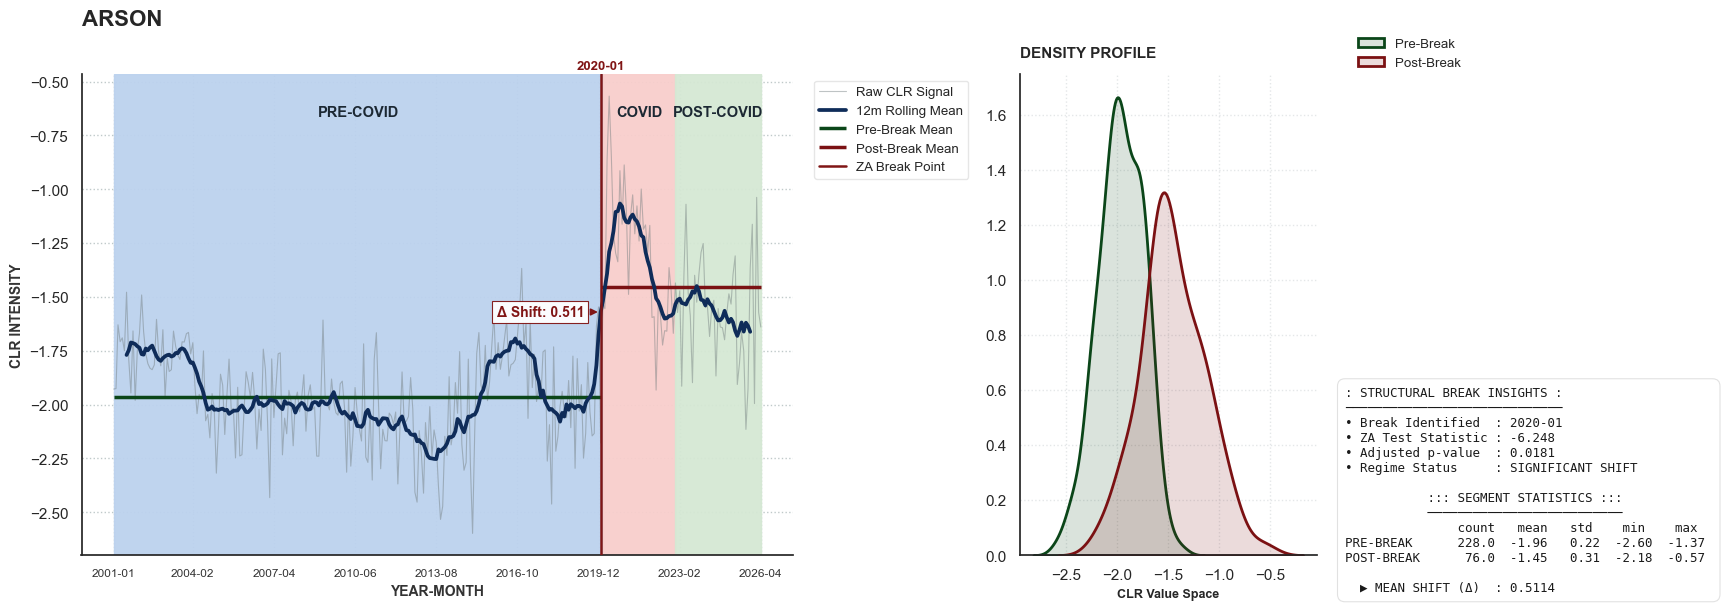

In [37]:
# Initialize values
window  = 12
category = 'Arson'
row = stat_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
arson_plot = plot.plot_structural_break(
        clr_df, 
        category, 
        break_date=za_date,
        window=window,
        za_stat=za_stat, 
        za_p_adj=za_p_adj, 
        era_boundaries=cfg.era_boundaries
)

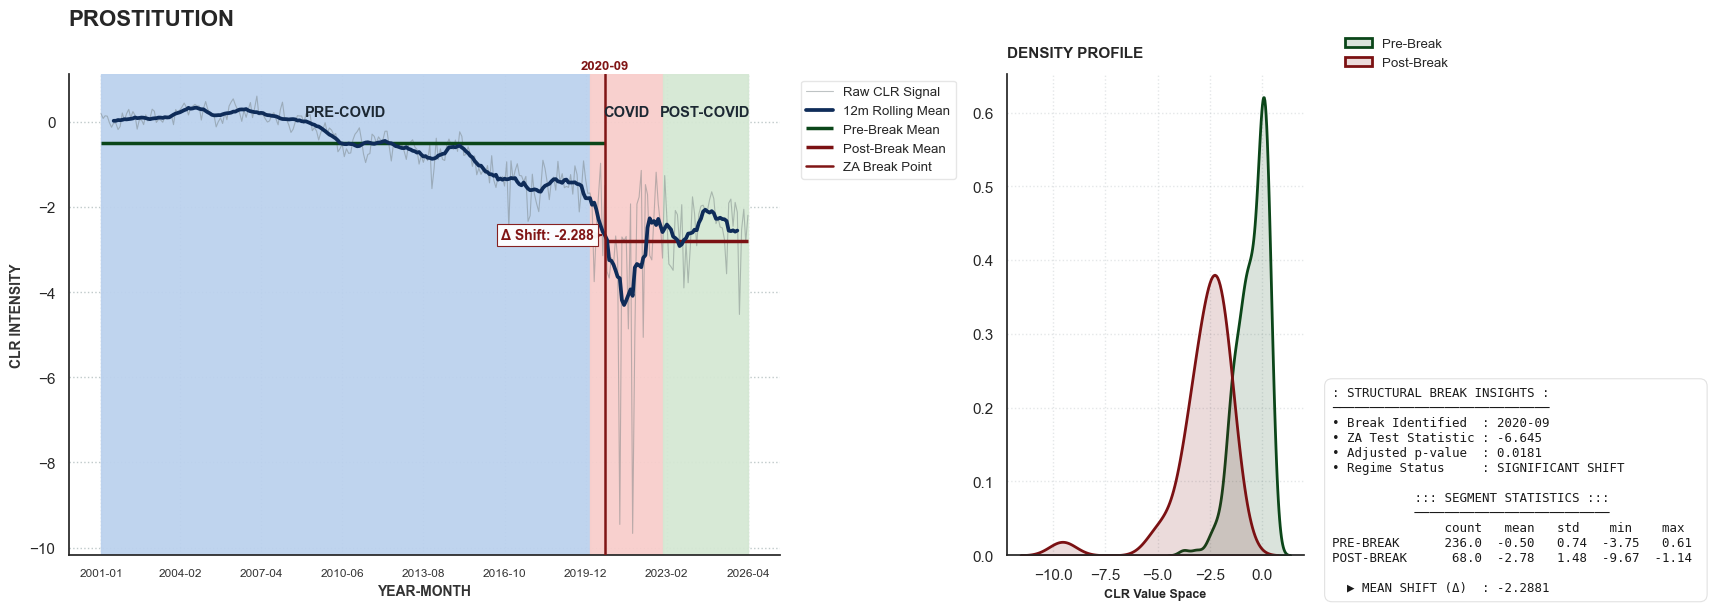

In [38]:
# Initialize values
category = 'Prostitution'
row = stat_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
gambling_plot = plot.plot_structural_break(
        clr_df, 
        category, 
        break_date=za_date,
        window=window,
        za_stat=za_stat, 
        za_p_adj=za_p_adj, 
        era_boundaries=cfg.era_boundaries
)

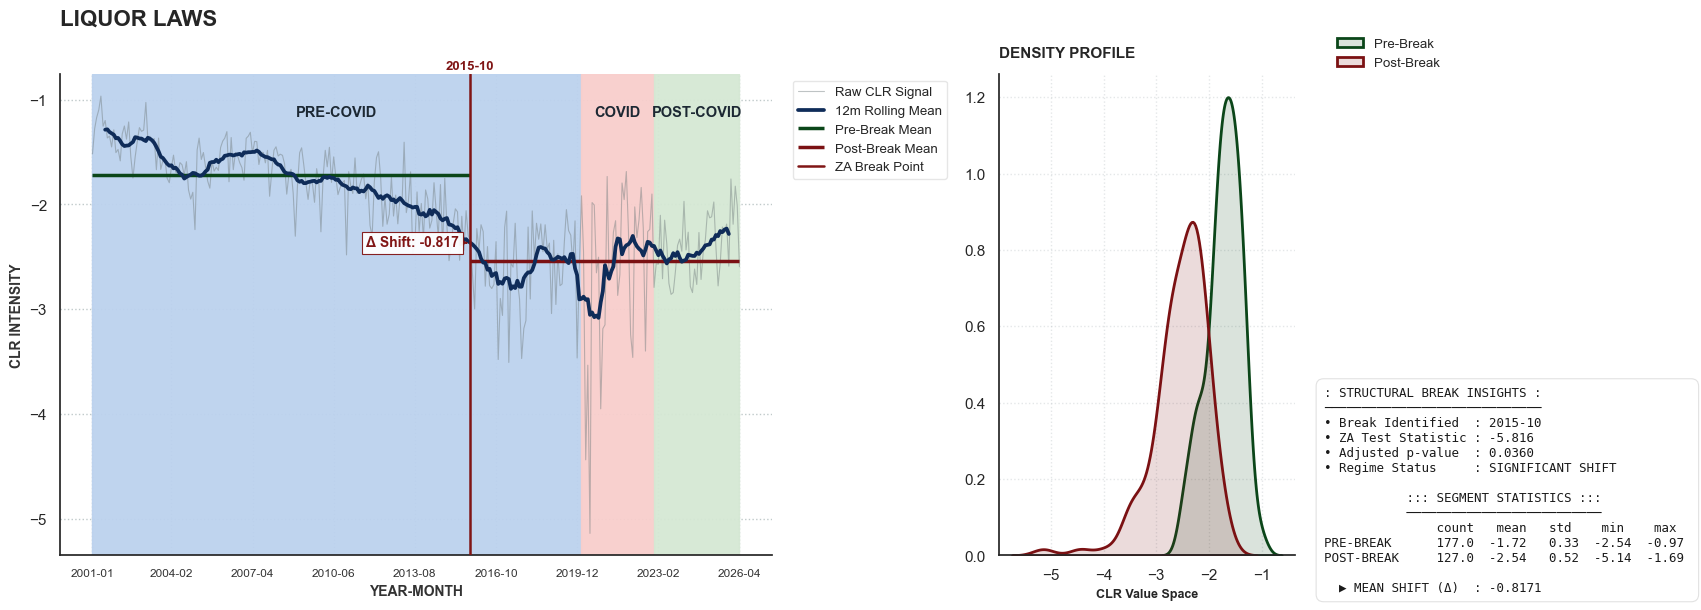

In [39]:
# Initialize values
category = 'Liquor Laws'
row = stat_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
gambling_plot = plot.plot_structural_break(
        clr_df, 
        category, 
        break_date=za_date,
        window=window,
        za_stat=za_stat, 
        za_p_adj=za_p_adj, 
        era_boundaries=cfg.era_boundaries
)

In [40]:
# Classify each dense category by ZA significance (using ADJUSTED p)
summary = stat_df[~stat_df['is_sparse']].copy()
summary['za_significant'] = summary['za_p_adj'] < 0.05

sig = summary[summary['za_significant']].sort_values('za_p_adj')
print(f"Significant structural breaks (ZA, FDR-adjusted, α=0.05): {len(sig)} of {len(summary)}")
print(sig[['za_date', 'za_stat', 'za_p', 'za_p_adj']].to_string())

print(f"\nNon-significant (no single clean break): {(~summary['za_significant']).sum()}")

Significant structural breaks (ZA, FDR-adjusted, α=0.05): 3 of 24
              za_date   za_stat      za_p  za_p_adj
crime                                              
Arson         2020-01 -6.248367  0.001510  0.018119
Prostitution  2020-09 -6.644741  0.000993  0.018119
Liquor Laws   2015-10 -5.816199  0.004505  0.036042

Non-significant (no single clean break): 21


#### 📌 Summary

> - The stationarity and structural-break analysis show that Chicago's crime composition changed over time, but not all categories changed in the same way or at the same time. Most categories were non-stationary, meaning their relative shares evolved gradually across the 2001–2026 period rather than remaining stable. Formal Zivot-Andrews testing, after correcting for multiple comparisons, identified only three categories with statistically significant single structural breaks: Arson, Prostitution, and Liquor Laws. Prostitution experienced the largest confirmed shift, dropping sharply during the COVID period and remaining at a much lower level afterward, while Arson stepped up to a new, stable level in early 2020. Liquor Laws showed a significant break much earlier, in 2015, demonstrating that important structural changes were already underway well before the pandemic.
> - By contrast, categories such as Weapons Violations and Homicide displayed strong COVID-era movement visually, yet the statistical tests indicated these changes were better explained by gradual trends or temporary spikes than by permanent regime shifts.
> - Overall, the findings suggest that Chicago's crime composition evolved mainly through long-term gradual change, punctuated by only a small number of true structural breaks. COVID clearly contributed an important shock to the system, most notably for Prostitution, but it was not the sole driver of change. The results also underscore the value of formal statistical testing: several categories that appeared to "break" on visual inspection were, in fact, trending over many years or later partially reverted. Together, the analyses support a more nuanced interpretation than a single-moment disruption: Chicago's crime structure was already changing before 2020, and the pandemic intensified or accelerated some of those ongoing shifts rather than resetting the system at one point in time.

### Step 6b: Block Bootstrap Test

In [41]:
# Bootstrap Comparison of Eras
sparse_cats = ['Gambling']

# Pre-COVID vs COVID
bootstrap_pc = clr.run_era_comparison(
    clr_era['Pre-COVID'], clr_era['COVID'],
    label1='Pre-COVID', label2='COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True
)


🧬 BOOTSTRAP INFERENCE: Pre-COVID vs COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: Pre-COVID vs COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Aggravated Assault                      0.9574       4.4956     0.0001     0.0002   ✨ Significant
Weapons Violations                      1.5779       4.4354     0.0001     0.0002   ✨ Significant
Simple Assault                          0.4132       3.7034     0.0001     0.0002   ✨ Significant
Aggravated Battery                      0.6270       3.4709     0.0001     0.0002   ✨ Significant
Drug Abuse Violations                  -1.0998      -3.1905     0.0001     0.0002   ✨ Significant
Vandalism                               0.3387       3.1148     0.0001     0.0002   ✨ Significant
Homicide - 1st or 2nd Degree            1.2000       3.0504     0.0001     0.0002   ✨ Significant
Arson            

In [42]:
# COVID vs Post-COVID
bootstrap_cp = clr.run_era_comparison(
    clr_era['COVID'], clr_era['Post-COVID'],
    label1='COVID', label2='Post-COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True
)


🧬 BOOTSTRAP INFERENCE: COVID vs Post-COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: COVID vs Post-COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Homicide - 1st or 2nd Degree           -0.5209      -2.0841     0.0009     0.0216   ✨ Significant
Weapons Violations                     -0.3726      -1.9576     0.0024     0.0288   ✨ Significant
Motor Vehicle Theft                     0.3864       1.2255     0.0257     0.1028   🚫 Not Significant
Aggravated Battery                     -0.1825      -1.1011     0.0175     0.0955   🚫 Not Significant
Burglary                               -0.2092      -1.0083     0.0049     0.0392   ✨ Significant
Arson                                  -0.2772      -1.0046     0.0199     0.0955   🚫 Not Significant
Larceny - Theft                         0.1542       0.8548     0.0391     0.1168   🚫 Not Significant

In [43]:
# Pre-COVID vs Post-COVID
bootstrap_pp = clr.run_era_comparison(
    clr_era['Pre-COVID'], clr_era['Post-COVID'],
    label1='Pre-COVID', label2='Post-COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True
)


🧬 BOOTSTRAP INFERENCE: Pre-COVID vs Post-COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: Pre-COVID vs Post-COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Motor Vehicle Theft                     0.9571       5.0834     0.0001     0.0001   ✨ Significant
Aggravated Assault                      0.8600       4.1202     0.0001     0.0001   ✨ Significant
Simple Assault                          0.4178       3.6263     0.0001     0.0001   ✨ Significant
Weapons Violations                      1.2053       3.4113     0.0001     0.0001   ✨ Significant
Drug Abuse Violations                  -1.0287      -3.0304     0.0001     0.0001   ✨ Significant
Prostitution                           -2.0202      -2.9889     0.0001     0.0001   ✨ Significant
Gambling                               -4.0630      -2.7902     0.0001         --   📌 SPARSE/BYPASS
Vanda

#### 📌 Summary

 > -The bootstrap analysis confirms a clear three-phase pattern in how Chicago's crime composition changed across eras. After flagging Gambling as a sparse category and excluding it from the multiple-testing correction, the results show that the transition from the pre-COVID period into COVID produced statistically significant changes across all 24 dense crime categories, indicating a broad system-wide disruption. The largest shifts occurred in violent and weapons-related offenses, while Drug Abuse Violations showed a major decline.
> - In contrast, the transition from the COVID period to the post-COVID era produced only three significant changes: Homicide, Weapons Violations, and Burglary, suggesting that the system largely stabilized after the initial pandemic shock rather than continuing to reorganize. However, when comparing the pre-COVID and post-COVID periods directly, 21 of the 24 dense categories remained significantly different, indicating that most COVID-era compositional changes persisted rather than fully reverting.
> - The findings also highlight the importance of interpreting statistical significance alongside effect size. In the COVID-to-post-COVID comparison, several categories with moderate effect sizes (such as Motor Vehicle Theft and Arson) did not survive the strict FDR correction, reflecting both the genuine stabilization of the system and the conservativeness of multiple-testing adjustment in a low-signal comparison.
> - Overall, the analysis demonstrates that the bootstrap method successfully distinguishes between broad structural disruption and later stabilization rather than simply labeling everything as significant. Together with the PCA, heatmaps, and structural-break testing, the results support a consistent conclusion: Chicago's crime composition was already evolving before 2020, COVID introduced a major system-wide shock, and the city afterward settled into a new long-term compositional structure rather than returning to its earlier baseline.

Pre-COVID   : diag==1 True | range [-0.83, +1.00]
COVID       : diag==1 True | range [-0.52, +1.00]
Post-COVID  : diag==1 True | range [-0.54, +1.00]


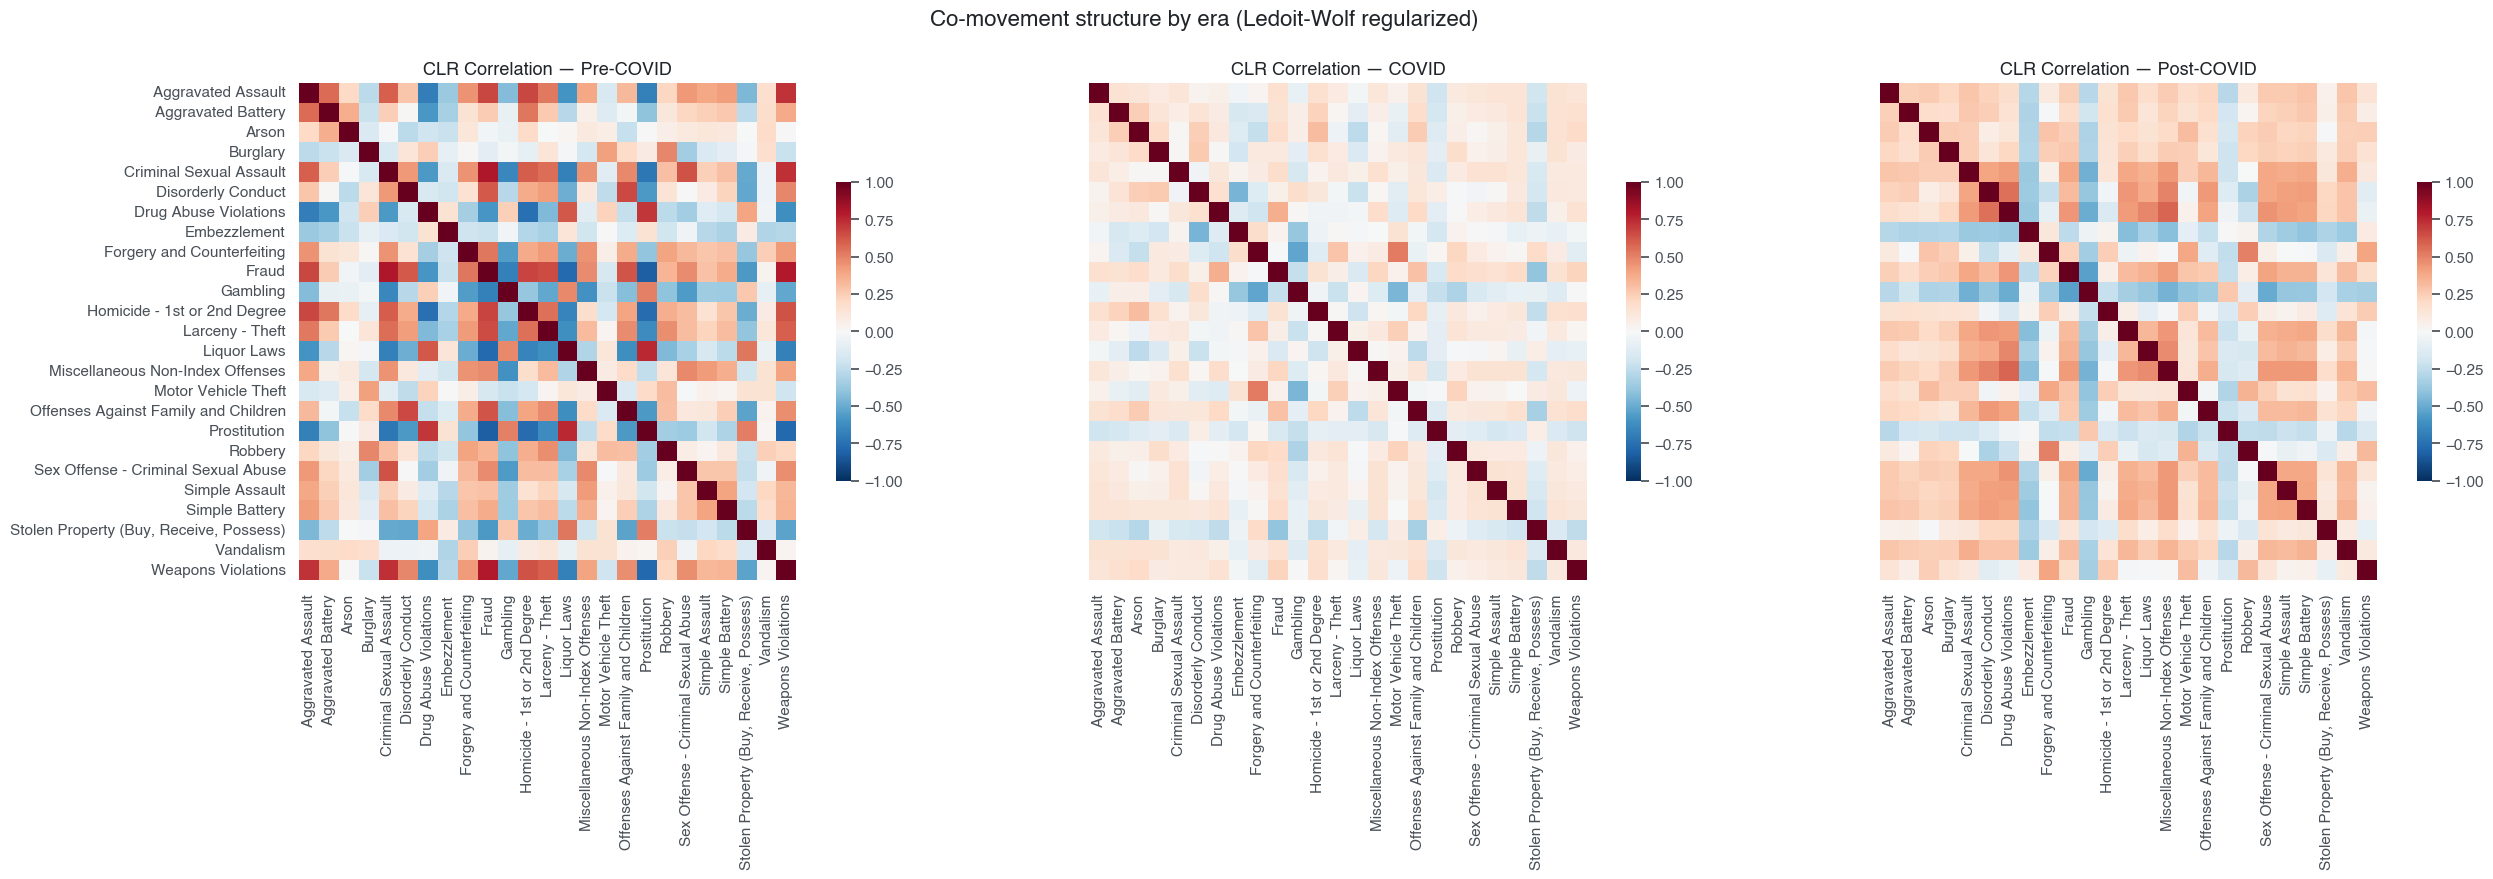

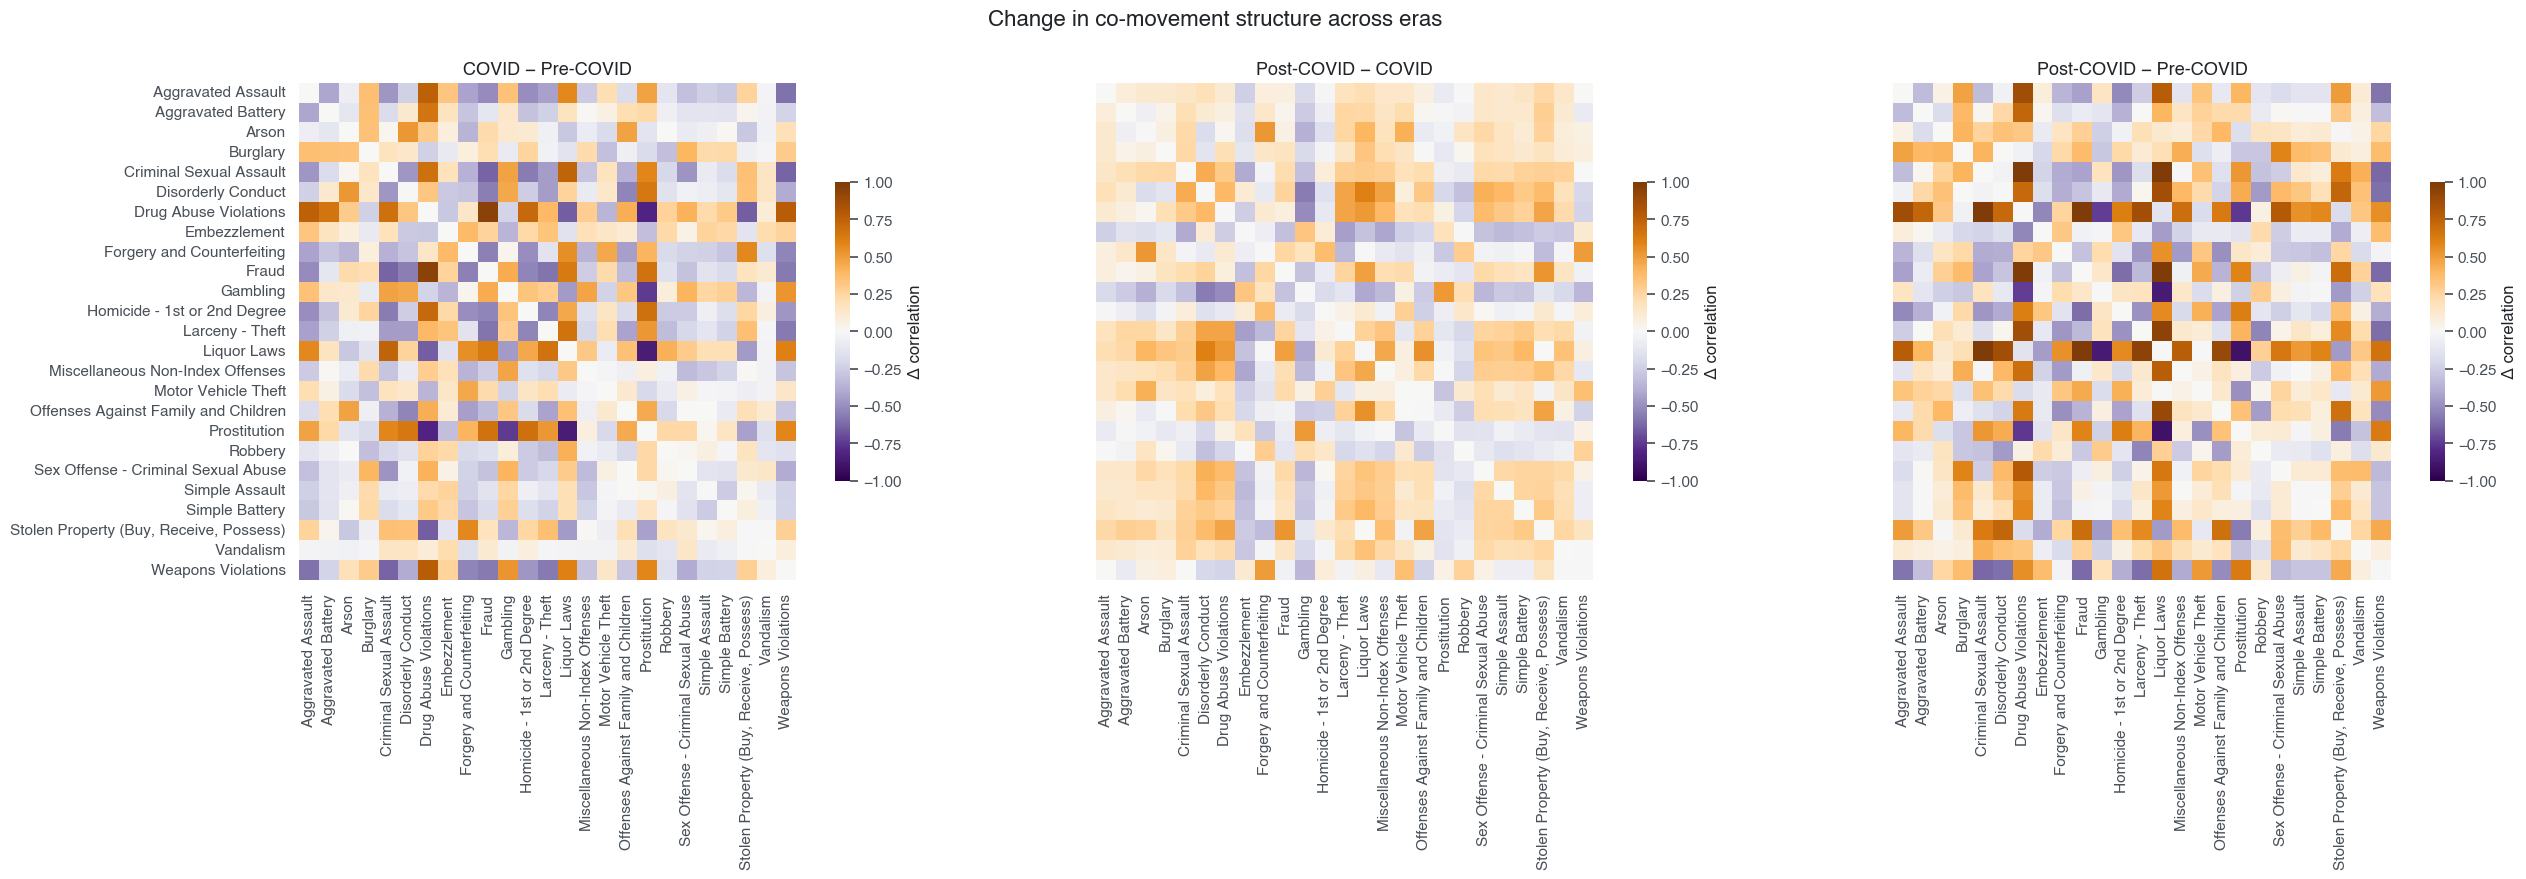

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Optional, Tuple


def cov_to_corr(cov: np.ndarray) -> np.ndarray:
    """Convert a covariance matrix to a correlation matrix. Zero-variance safe."""
    std = np.sqrt(np.diag(cov))
    denom = np.outer(std, std)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr = cov / denom
        corr[denom == 0] = 0
    return corr


def per_era_correlation_analysis(
    era_covs: Dict[str, pd.DataFrame],
    era_order: Tuple[str, ...] = ('Pre-COVID', 'COVID', 'Post-COVID'),
    verbose: bool = True,
) -> Dict[str, pd.DataFrame]:
    """
    Per-era co-movement analysis from (Ledoit-Wolf-regularized) covariance matrices.

    Builds correlation matrices per era and plots:
      (1) one correlation heatmap per era  -> "which crimes move together in each era"
      (2) three pairwise difference heatmaps -> "did co-movement change across eras"
          COVID-Pre, Post-COVID, Post-Pre.

    Parameters
    ----------
    era_covs : dict[str, pd.DataFrame]
        Covariance matrix per era (labeled DataFrames, K x K).
    era_order : tuple of str
        Era display order.
    verbose : bool
        If True, prints sanity checks.

    Returns
    -------
    corr_by_era : dict[str, pd.DataFrame]
        Correlation matrix per era.
    """
    # --- Build correlation matrices (labels travel with the DataFrames) ---
    cats = list(era_covs[era_order[0]].index)
    corr_by_era = {
        era: pd.DataFrame(cov_to_corr(era_covs[era].values), index=cats, columns=cats)
        for era in era_order
    }

    if verbose:
        for era in era_order:
            c = corr_by_era[era].values
            print(f"{era:12s}: diag==1 {np.allclose(np.diag(c), 1.0)} | "
                  f"range [{c.min():+.2f}, {c.max():+.2f}]")

    # --- Panel 1: correlation heatmap per era ---
    _plot_corr_grid(
        [(corr_by_era[era], f"CLR Correlation — {era}") for era in era_order],
        suptitle="Co-movement structure by era (Ledoit-Wolf regularized)",
        cmap='RdBu_r', cbar_label=None, vlim=1.0,
    )

    # --- Panel 2: all three pairwise difference heatmaps ---
    pre, cov, post = era_order  # assumes (Pre, COVID, Post) order
    diffs = [
        (corr_by_era[cov]  - corr_by_era[pre],  f"{cov} − {pre}"),
        (corr_by_era[post] - corr_by_era[cov],  f"{post} − {cov}"),
        (corr_by_era[post] - corr_by_era[pre],  f"{post} − {pre}"),
    ]
    _plot_corr_grid(
        diffs,
        suptitle="Change in co-movement structure across eras",
        cmap='PuOr_r', cbar_label='Δ correlation', vlim=1.0,
    )

    return corr_by_era


def set_modern_plot_style():
    """
    Apply a clean, modern, compact Matplotlib style.
    """
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
        'text.color': '#212529',
        'axes.labelcolor': '#212529',
        'xtick.color': '#495057',
        'ytick.color': '#495057',
        'figure.titlesize': 16,
        'figure.titleweight': 'bold',
        'axes.titlesize': 13,
        'axes.titleweight': 'bold',
        'figure.facecolor': '#ffffff',
        'axes.facecolor': '#ffffff',
    })

    
def _plot_corr_grid(panels, suptitle, cmap, cbar_label, vlim):
    """Internal: render a 1-row grid of correlation/difference heatmaps."""
    set_modern_plot_style()

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(9 * n, 8))
    if n == 1:
        axes = [axes]
    for i, (ax, (mat, title)) in enumerate(zip(axes, panels)):
        cbar_kws = {'shrink': 0.6}
        if cbar_label:
            cbar_kws['label'] = cbar_label
        sns.heatmap(
            mat, ax=ax, cmap=cmap, center=0, vmin=-vlim, vmax=vlim,
            square=True, cbar_kws=cbar_kws,
            xticklabels=True, yticklabels=(i == 0),  # y-labels only on first panel
        )
        ax.set_title(title, fontweight='bold')
        ax.tick_params(axis='x', labelrotation=90, labelsize=11)
        ax.tick_params(axis='y', labelsize=11)
    plt.suptitle(suptitle, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# --- Run ---
corr_by_era = per_era_correlation_analysis(eras_stat['era_covs_lw'])

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple


# ---------------------------------------------------------
# Modern global plotting style (clean, compact, slick)
# ---------------------------------------------------------
def set_modern_plot_style():
    """Apply a clean, modern, minimal, and slick Matplotlib style."""
    plt.rcParams.update({
        # Typography
        'font.family': 'sans-serif',
        'font.sans-serif': ['Inter', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
        'font.size': 11,
        'text.color': '#2b2b2b',

        # Axes + Labels
        'axes.labelcolor': '#2b2b2b',
        'axes.edgecolor': '#e0e0e0',
        'axes.linewidth': 0.8,
        'axes.titlesize': 16,
        'axes.titleweight': 'semibold',
        'axes.titlepad': 10,

        # Ticks
        'xtick.color': '#555555',
        'ytick.color': '#555555',
        'xtick.major.size': 3,
        'ytick.major.size': 3,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,

        # Figure (suptitle inherits these)
        'figure.facecolor': '#ffffff',
        'figure.titlesize': 20,        # suptitle default size
        'figure.titleweight': 'bold',  # suptitle default weight
        'figure.subplot.left': 0.05,   # cleaner margins
        'figure.subplot.right': 0.95,
        'figure.subplot.top': 0.92,
        'figure.subplot.bottom': 0.08,

        # Heatmap defaults
        'image.cmap': 'coolwarm',
        'image.interpolation': 'nearest',

        # Savefig
        'savefig.facecolor': '#ffffff',
        'savefig.dpi': 150,
    })



# ---------------------------------------------------------
# Covariance → Correlation conversion
# ---------------------------------------------------------
def cov_to_corr(cov: np.ndarray) -> np.ndarray:
    """Convert covariance matrix to correlation matrix (zero-variance safe)."""
    std = np.sqrt(np.diag(cov))
    denom = np.outer(std, std)

    with np.errstate(divide='ignore', invalid='ignore'):
        corr = cov / denom
        corr[denom == 0] = 0

    return corr


# ---------------------------------------------------------
# Internal: render a row of heatmaps
# ---------------------------------------------------------
def _plot_corr_grid(
    panels,
    suptitle: str,
    cmap: str,
    cbar_label: str,
    vlim: float
):
    """Render a 1-row grid of correlation/difference heatmaps."""
    set_modern_plot_style()

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(8.5 * n, 6), constrained_layout=True)
    axes = [axes] if n == 1 else axes

    for i, (ax, (mat, title)) in enumerate(zip(axes, panels)):
        cbar_kws = {'shrink': 0.65}
        if cbar_label:
            cbar_kws['label'] = cbar_label

        sns.heatmap(
            mat.to_numpy(dtype=float),       # PyArrow → NumPy float
            ax=ax,
            cmap=cmap,
            center=0,
            vmin=-vlim,
            vmax=vlim,
            square=True,
            cbar_kws=cbar_kws,
            xticklabels=False,
            yticklabels=mat.index if i == 0 else False,
            linewidths=0.3,
            linecolor='#e9ecef'
        )

        ax.set_title(title, pad=8)
        ax.tick_params(axis='y')
        # ax.tick_params(axis='y', labelsize=10)
        sns.despine(ax=ax, left=True, bottom=True)

    fig.suptitle(suptitle, y=1.08)
    plt.show()


# ---------------------------------------------------------
# Main analysis function (modern, compact, slick)
# ---------------------------------------------------------
def per_era_correlation_analysis(
    era_covs: Dict[str, pd.DataFrame],
    era_order: Tuple[str, ...] = ('Pre-COVID', 'COVID', 'Post-COVID'),
    verbose: bool = True,
) -> Dict[str, pd.DataFrame]:
    """Compute per-era correlation matrices and visualize."""
    
    cats = list(era_covs[era_order[0]].index)

    # Build PyArrow-backed correlation matrices
    corr_by_era = {
        era: pd.DataFrame(
            cov_to_corr(era_covs[era].loc[cats, cats].to_numpy()),
            index=cats,
            columns=cats,
            dtype="double[pyarrow]"
        )
        for era in era_order
    }

    if verbose:
        print(f"\n{'📊 Correlation Matrix Diagnostics':^55}")
        print("─" * 55)
    
        for era in era_order:
            arr = corr_by_era[era].to_numpy(dtype=float)
            diag_ok = np.allclose(np.diag(arr), 1.0)
            rmin, rmax = arr.min(), arr.max()
    
            print(f"• {era:<12}  │  Diag: {str(diag_ok):<5}  │  Range: {rmin:+.2f} → {rmax:+.2f}")
    
        print()


    # Panel 1: correlations
    _plot_corr_grid(
        [(corr_by_era[era], f"{era} Correlation") for era in era_order],
        suptitle="Co-movement Structure by Era",
        cmap='coolwarm',
        cbar_label=None,
        vlim=1.0,
    )

    # Panel 2: differences
    pre, cov, post = era_order
    diffs = [
        (corr_by_era[cov]  - corr_by_era[pre],  f"{cov} − {pre}"),
        (corr_by_era[post] - corr_by_era[cov],  f"{post} − {cov}"),
        (corr_by_era[post] - corr_by_era[pre],  f"{post} − {pre}"),
    ]

    _plot_corr_grid(
        diffs,
        suptitle="Change in Co-movement Structure Across Eras",
        cmap='PiYG',
        cbar_label='Δ correlation',
        vlim=1.0,
    )

    return corr_by_era



           📊 Correlation Matrix Diagnostics            
───────────────────────────────────────────────────────
• Pre-COVID     │  Diag: True   │  Range: -0.83 → +1.00
• COVID         │  Diag: True   │  Range: -0.52 → +1.00
• Post-COVID    │  Diag: True   │  Range: -0.54 → +1.00



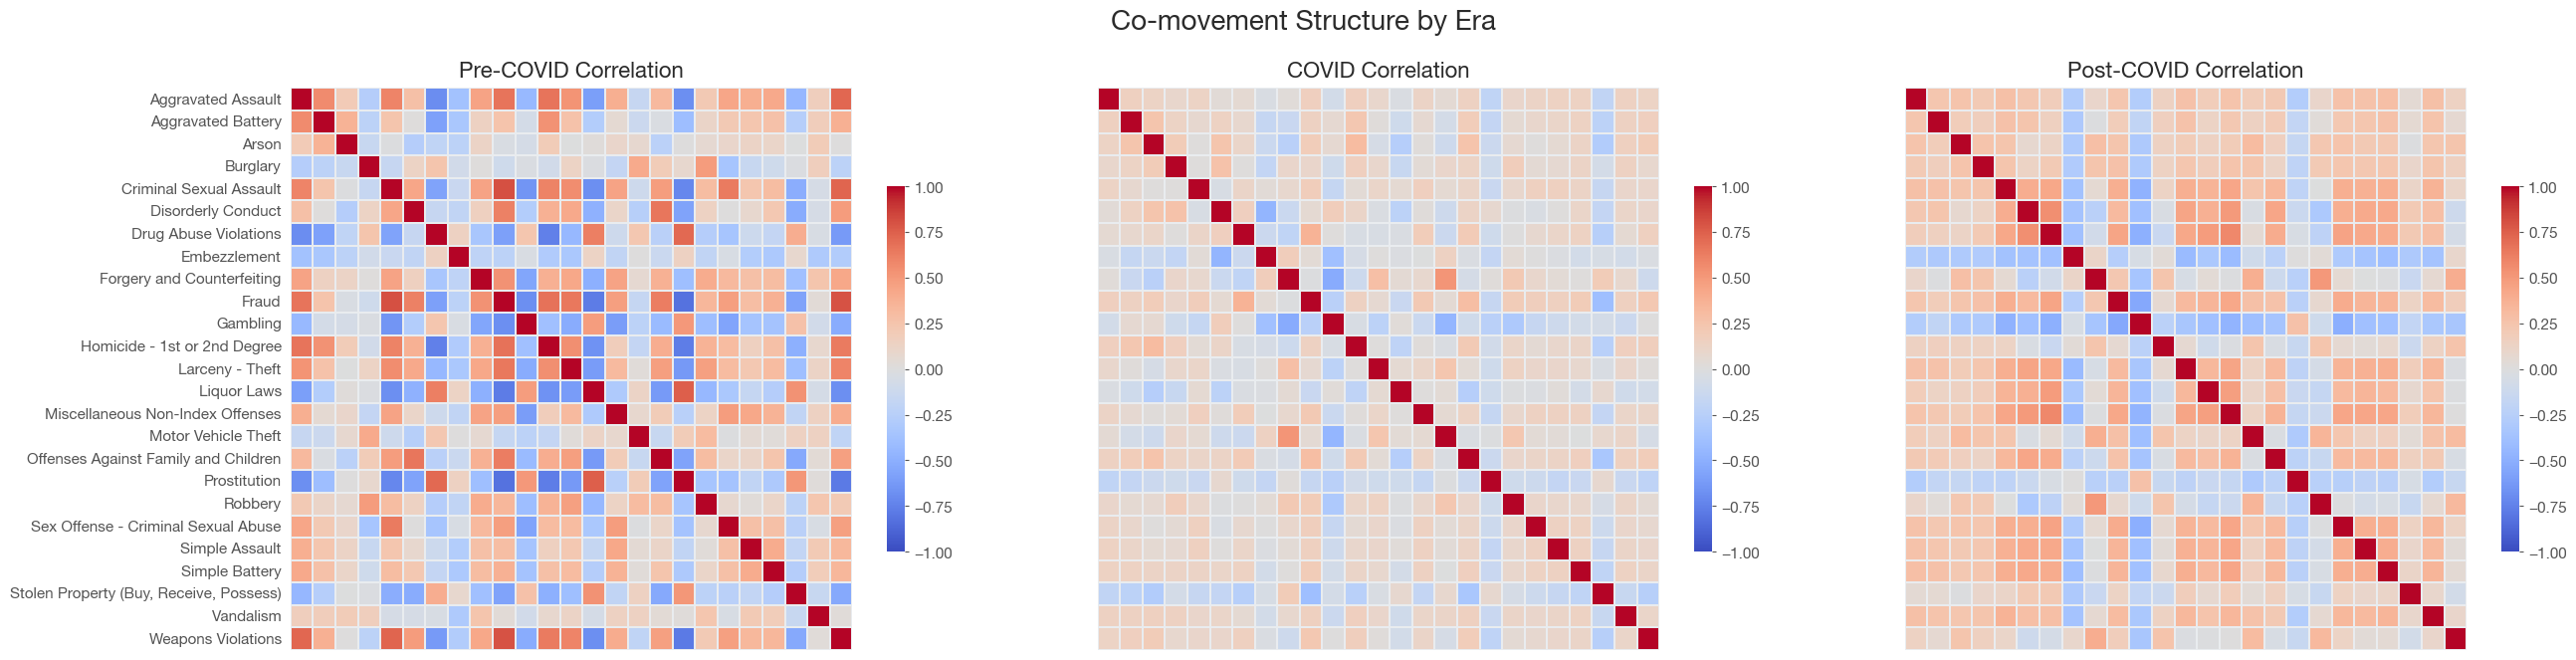

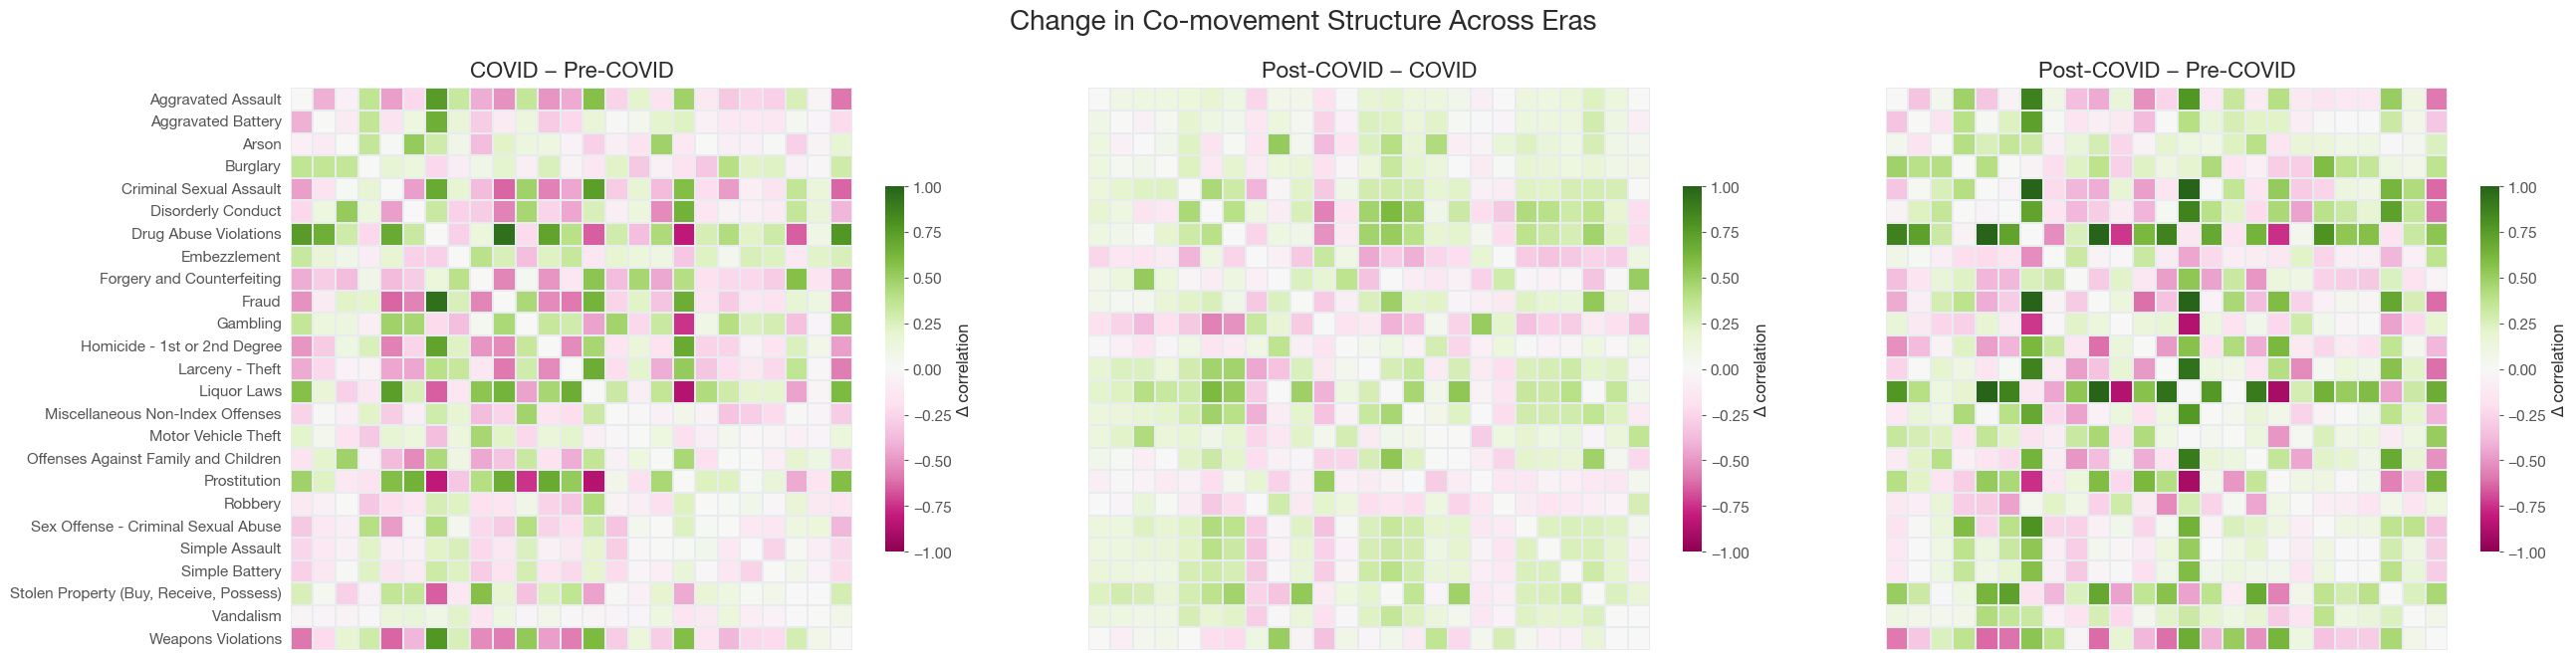

In [99]:
# --- Run ---
corr_by_era = per_era_correlation_analysis(eras_stat['era_covs_lw'])

In [100]:
print(eras_stat['lw_shrinkage'])

{'Pre-COVID': np.float64(0.05231891855186645), 'COVID': np.float64(0.1516089791774052), 'Post-COVID': np.float64(0.0879169445558826)}


In [103]:
print(clr_era['COVID'].shape)        # expect (34, 25)
print(clr_era['Pre-COVID'].shape)    # expect (230, 25)
print(clr_era['Post-COVID'].shape)   # expect (40, 25)

(34, 25)
(230, 25)
(40, 25)



     📉 Ledoit–Wolf Shrinkage Diagnostics      
──────────────────────────────────────────────
• Pre-COVID    │ λₑᵣₐ = 0.0523
• COVID        │ λₑᵣₐ = 0.1516
• Post-COVID   │ λₑᵣₐ = 0.0879

→ Common shrinkage (max) │ λ* = 0.1516


           📊 Correlation Matrix Diagnostics            
───────────────────────────────────────────────────────
• Pre-COVID     │  Diag: True   │  Range: -0.77 → +1.00
• COVID         │  Diag: True   │  Range: -0.52 → +1.00
• Post-COVID    │  Diag: True   │  Range: -0.45 → +1.00



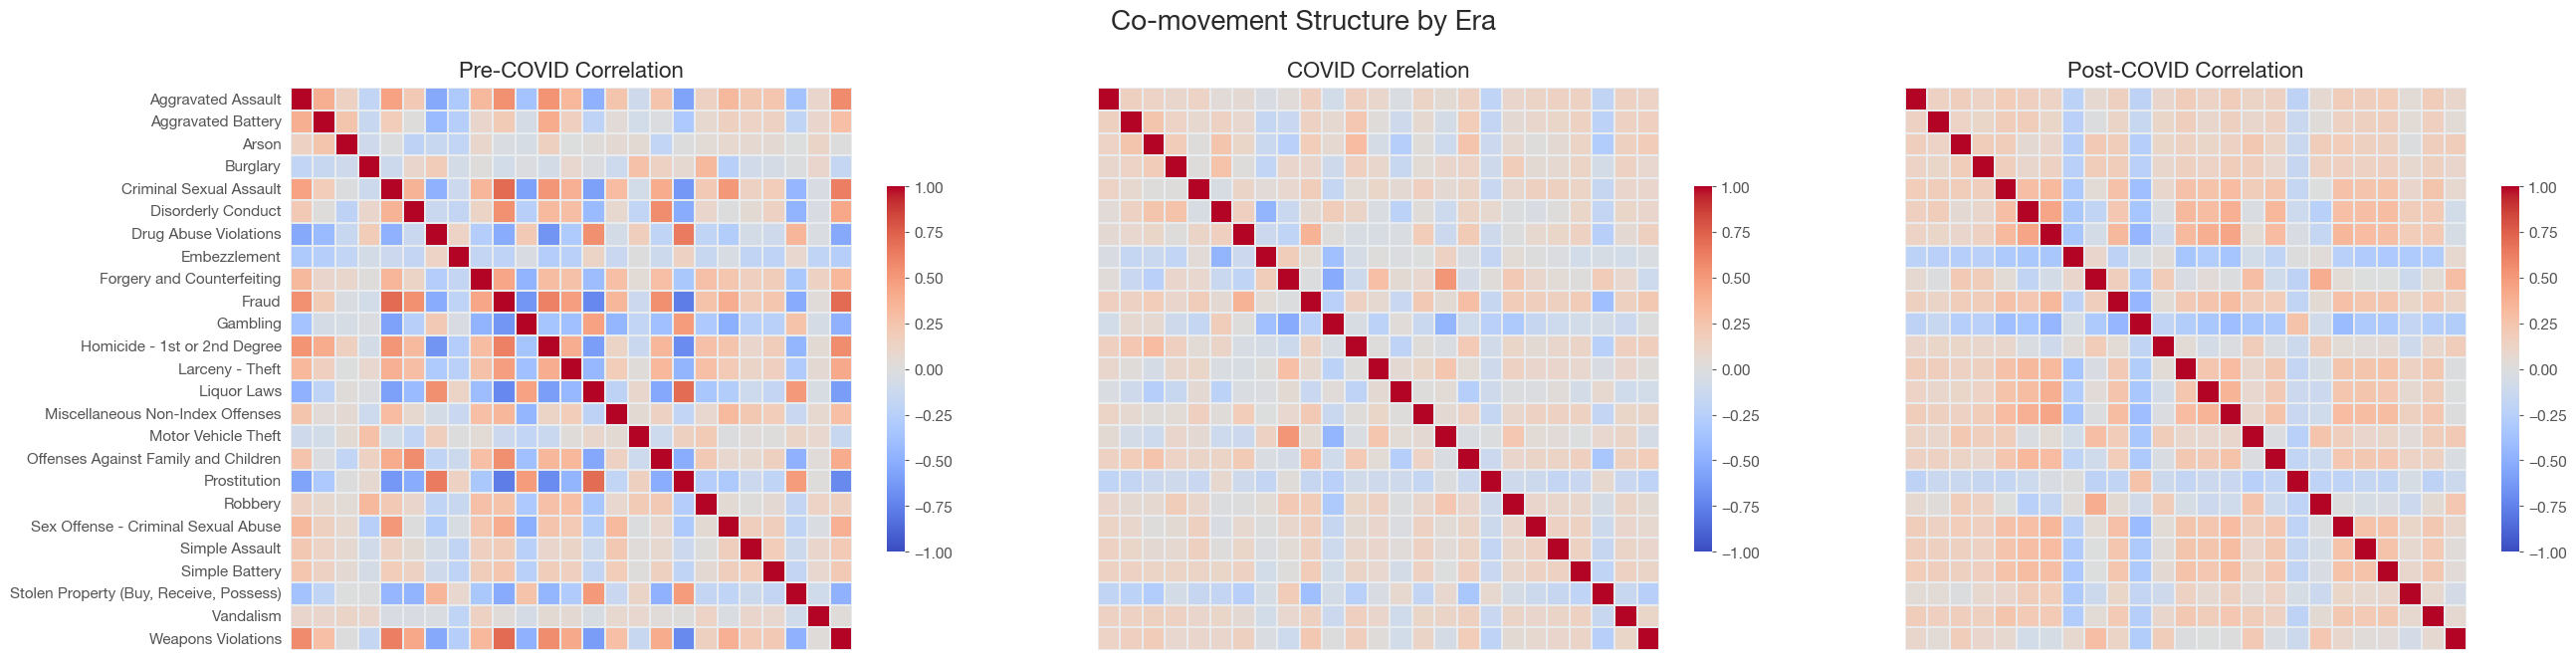

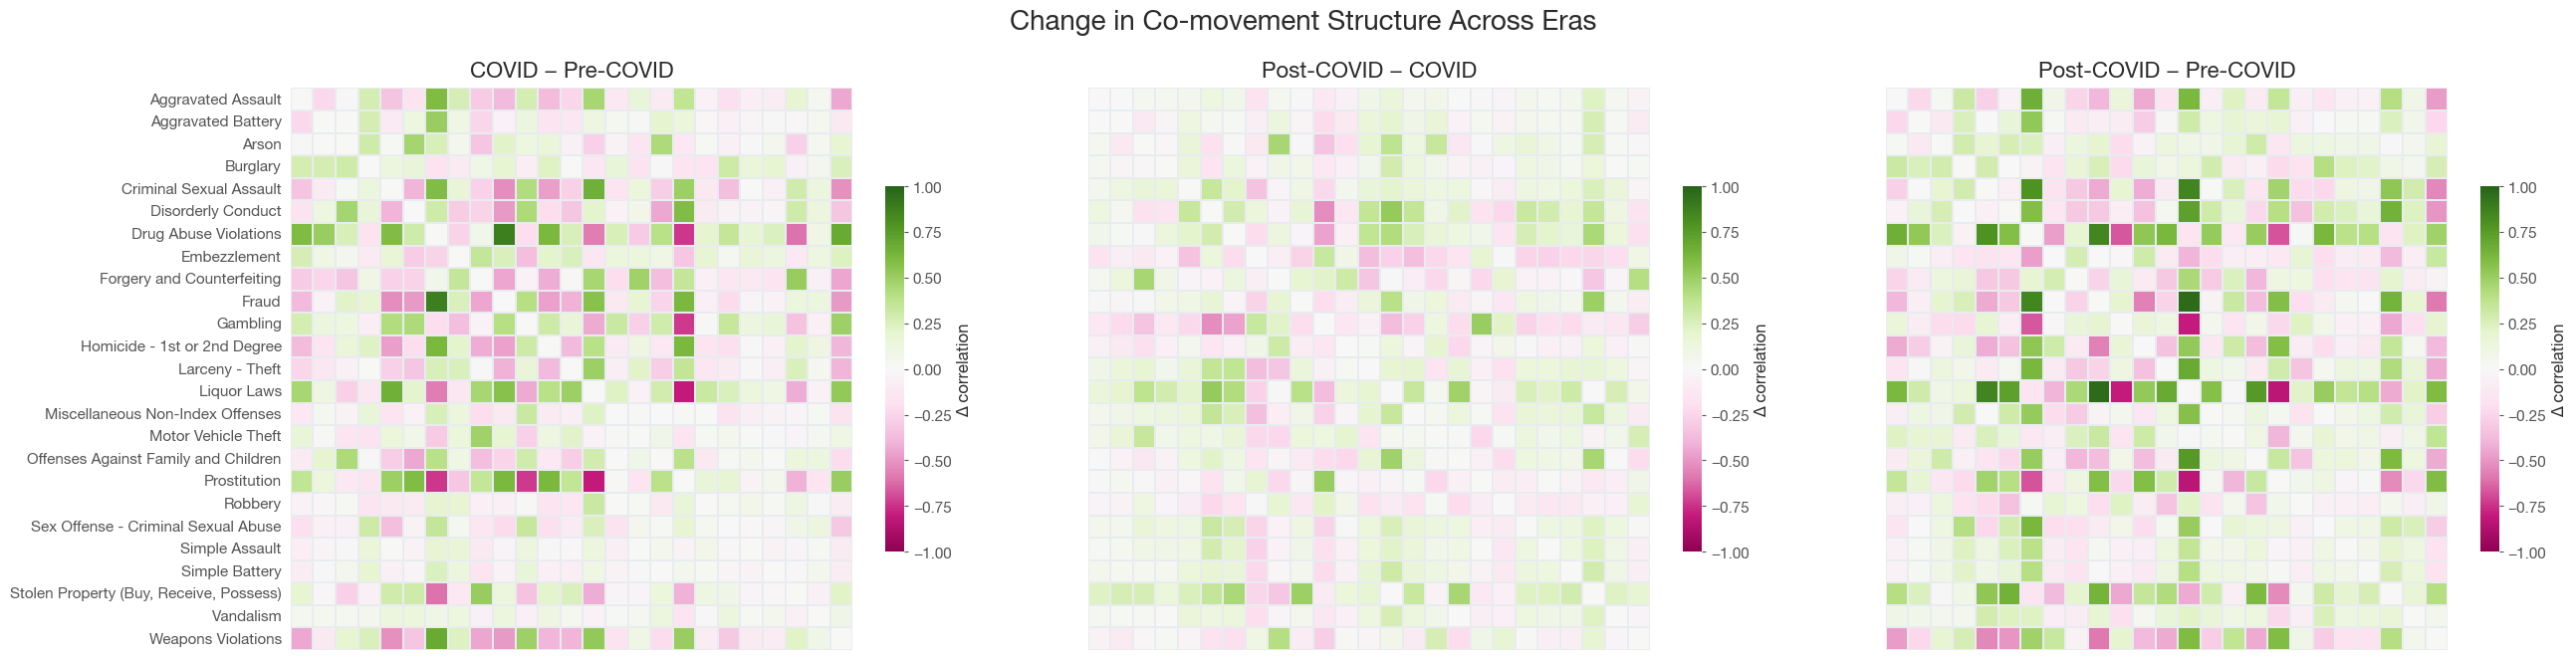

In [109]:
import numpy as np
import pandas as pd
from sklearn.covariance import ledoit_wolf, empirical_covariance


def fixed_shrinkage_cov(X: np.ndarray, lam: float) -> np.ndarray:
    """
    Covariance with a FIXED shrinkage intensity (not auto-selected).
    Uses scikit-learn's empirical_covariance as the base.
    """
    S = empirical_covariance(X)
    p = S.shape[0]
    mu = np.trace(S) / p
    target = mu * np.eye(p)
    return (1.0 - lam) * S + lam * target


def per_era_cov_common_shrinkage(
    clr_era: dict,
    era_order=('Pre-COVID', 'COVID', 'Post-COVID'),
    lam: float = None,
    verbose: bool = True
) -> tuple[dict[str, pd.DataFrame], float]:
    """
    Re-estimate per-era covariances with a COMMON shrinkage intensity.
    """
    # Determine the common lambda using scikit-learn's ledoit_wolf
    if lam is None:
        auto_lams = {}
        for era in era_order:
            _, lw_lam = ledoit_wolf(clr_era[era].values)
            auto_lams[era] = lw_lam
        lam = max(auto_lams.values())


        if verbose:
            print(f"\n{'📉 Ledoit–Wolf Shrinkage Diagnostics':^46}")
            print("─" * 46)
        
            for era, lam_era in auto_lams.items():
                print(f"• {era:<12} │ λₑᵣₐ = {lam_era:.4f}")
        
            print(f"\n→ Common shrinkage (max) │ λ* = {lam:.4f}\n")



    cats = clr_era[era_order[0]].columns

    # Plain float64 DataFrames (covariances are tiny 25x25 — no pyarrow needed,
    # and plain float64 avoids NumPy-interop issues in downstream cov_to_corr).
    cov_by_era = {
        era: pd.DataFrame(
            fixed_shrinkage_cov(clr_era[era].values, lam),
            index=cats,
            columns=cats,
        )
        for era in era_order
    }

    return cov_by_era, lam


# Re-estimate covariances with common shrinkage
cov_common, lam_used = per_era_cov_common_shrinkage(clr_era, lam=None)

# Run the correlation analysis on the comparable matrices
corr_by_era = per_era_correlation_analysis(cov_common)

In [116]:
import numpy as np

def offdiag(m):
    """Off-diagonal elements as a clean float64 array."""
    arr = np.asarray(m.values, dtype=float)      # ← coerce to float64
    mask = ~np.eye(arr.shape[0], dtype=bool)
    return arr[mask]

# Use whichever corr dict is your final one — the POOLED version:
pre  = corr_pooled['Pre-COVID']
cov  = corr_pooled['COVID']
post = corr_pooled['Post-COVID']

for a, b, name in [(pre, cov, 'Pre→COVID'),
                   (cov, post, 'COVID→Post'),
                   (pre, post, 'Pre→Post')]:
    d = offdiag(a) - offdiag(b)
    print(f"{name:12s}: mean|Δ|={np.abs(d).mean():.3f}  "
          f"max|Δ|={np.abs(d).max():.3f}  "
          f"frac|Δ|>0.2={np.mean(np.abs(d) > 0.2):.1%}")

print("\nMatrix similarity (correlation of off-diagonals):")
print(f"  Pre vs COVID:  {np.corrcoef(offdiag(pre), offdiag(cov))[0,1]:.3f}")
print(f"  Pre vs Post:   {np.corrcoef(offdiag(pre), offdiag(post))[0,1]:.3f}")
print(f"  COVID vs Post: {np.corrcoef(offdiag(cov), offdiag(post))[0,1]:.3f}")

Pre→COVID   : mean|Δ|=0.284  max|Δ|=1.240  frac|Δ|>0.2=56.0%
COVID→Post  : mean|Δ|=0.280  max|Δ|=0.845  frac|Δ|>0.2=58.7%
Pre→Post    : mean|Δ|=0.373  max|Δ|=1.340  frac|Δ|>0.2=70.0%

Matrix similarity (correlation of off-diagonals):
  Pre vs COVID:  0.552
  Pre vs Post:   0.395
  COVID vs Post: 0.554


Pooled λ from full series: 0.0180

           📊 Correlation Matrix Diagnostics            
───────────────────────────────────────────────────────
• Pre-COVID     │  Diag: True   │  Range: -0.85 → +1.00
• COVID         │  Diag: True   │  Range: -0.63 → +1.00
• Post-COVID    │  Diag: True   │  Range: -0.72 → +1.00



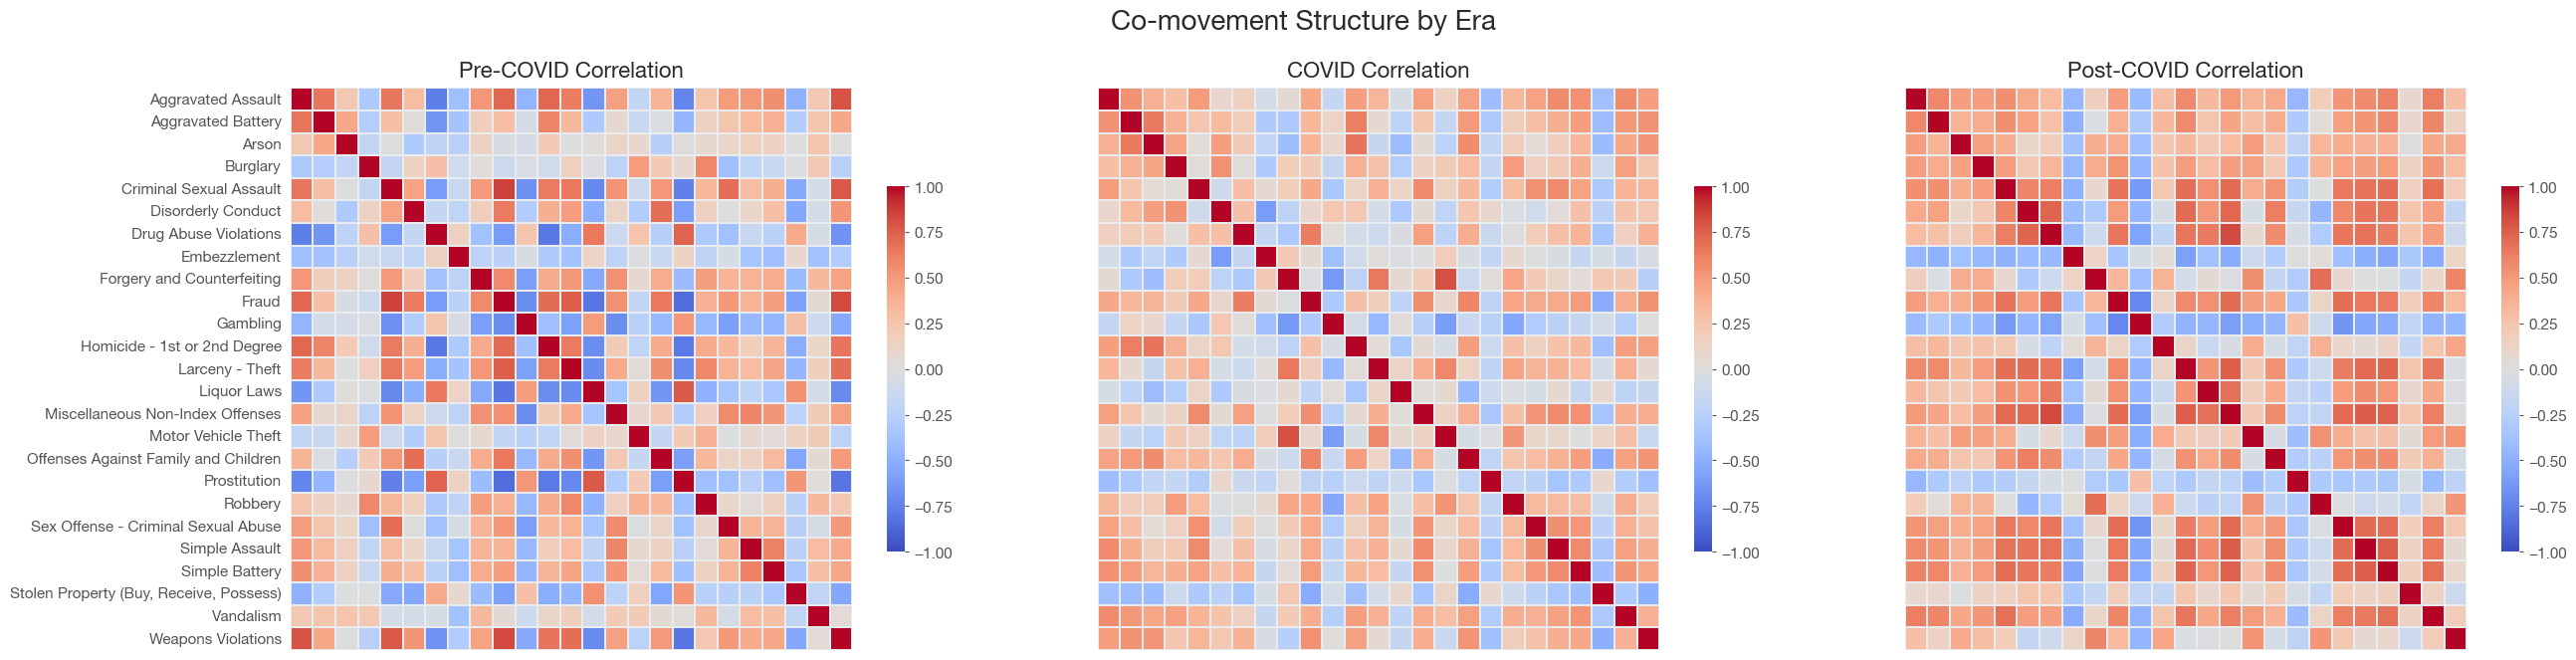

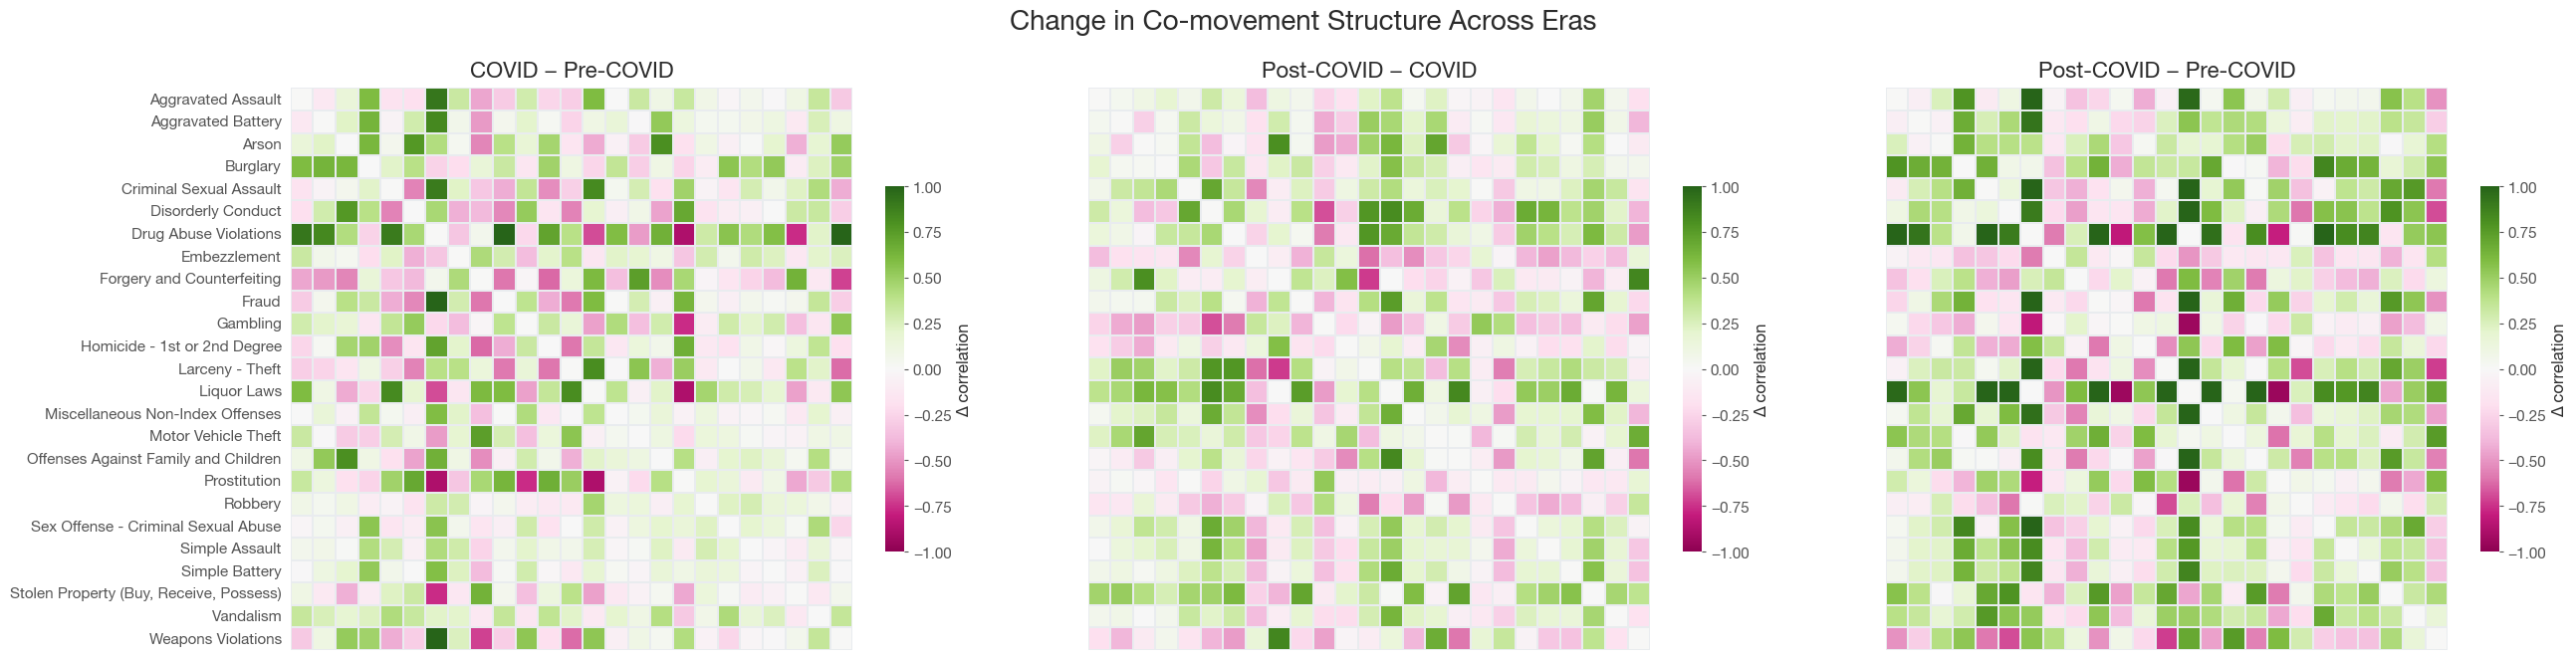

In [111]:
from sklearn.covariance import ledoit_wolf
# Pooled lambda from the full series (concatenate all eras)
full = np.vstack([clr_era[e].values for e in ['Pre-COVID','COVID','Post-COVID']])
_, lam_pooled = ledoit_wolf(full)
print(f"Pooled λ from full series: {lam_pooled:.4f}")

cov_pooled, _ = per_era_cov_common_shrinkage(clr_era, lam=lam_pooled)
corr_pooled = per_era_correlation_analysis(cov_pooled)